# Dataset Analysis

In [ ]:
from src.config import *
OUT_PATH = f"../results/RQ1/{DATASET_NAME}_llm_clones.json"
FINAL_DATASET = f"../results/RQ1/{DATASET_NAME}_clone_dataset.json"
REPROMPT_PATH = f"../results/RQ1/{DATASET_NAME}_reprompt.json"
FAILED_REPROMPT_PATH = f"../results/RQ1/{DATASET_NAME}_failed_reprompt.json"
FILTERED_PATH_CODEBLEU = f"../results/RQ1/{DATASET_NAME}_filtered_codebleu.json"
FILTERED_PATH_TESTS = f"../results/RQ1/{DATASET_NAME}_filtered_tests.json"
CLUSTER_DIR = "../results/RQ1/clustering"

Saved clusters for entry BigCodeBench/924 in ../results/RQ2/clustering/clusters\BigCodeBench/924
Saved all representatives for entry BigCodeBench/924 in ../results/RQ2/clustering\representatives\BigCodeBench_924\BigCodeBench_924_representatives.py


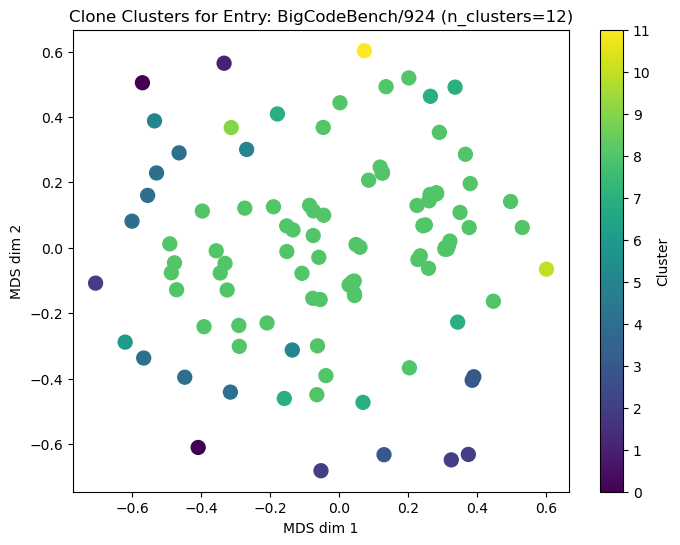

In [10]:
from src.steps.clustering import cluster_and_plot
import json
with open(FILTERED_PATH_TESTS, "r", encoding="utf-8") as f:
    data = json.load(f) 

cluster_and_plot(data[4])

## Refactorings

In [11]:
import json
import numpy as np
from collections import Counter
 

# === LOAD DATA ===
with open(OUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

if isinstance(data, dict):  # ensure list
    data = [data]

# === COUNT REFACTORINGS ===
refac_counter = Counter()

for entry in data:
    for clone in entry.get("clones", []):
        refacs = clone.get("refacs", [])
        if isinstance(refacs, list):
            refac_counter.update(refacs)
        elif isinstance(refacs, str):
            refac_counter[refacs] += 1

# === COMPUTE STATISTICS ===
counts = list(refac_counter.values())

if not counts:
    print("⚠️ No refactoring data found.")
else:
    min_count = min(counts)
    max_count = max(counts)
    avg_count = np.mean(counts)
    std_count = np.std(counts) 

    print("=== Individual Refactoring Counts ===")
    for refac, count in sorted(refac_counter.items(), key=lambda x: x[0]):
        print(f"{refac}: {count}")


=== Individual Refactoring Counts ===
refac_1: 4800
refac_2: 4800
refac_3: 4800
refac_4: 4800
refac_5: 4800
refac_6: 4800
refac_7: 4800


## Overall

### Codebleu

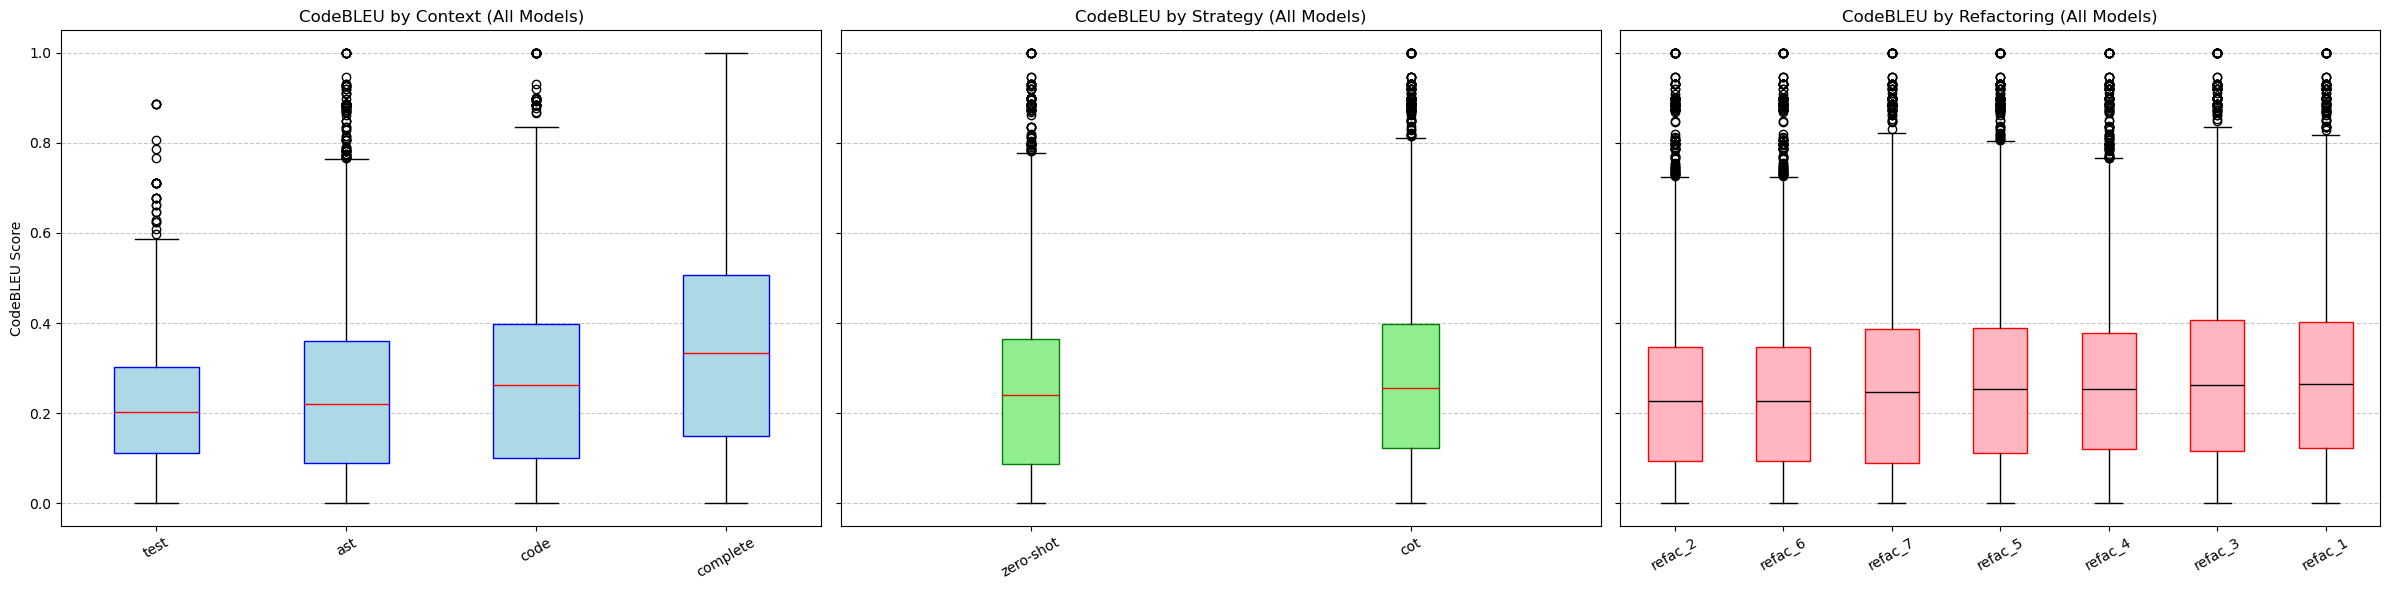

In [12]:
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# --- Load dataset ---
with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# --- Collect all scores (aggregated across all models) ---
scores_by_context = defaultdict(list)
scores_by_strategy = defaultdict(list)
scores_by_refac = defaultdict(list)

for entry in dataset:
    for clone in entry.get("clones", []):
        context = clone.get("context", "unknown")
        strategy = clone.get("strategy", "unknown")
        score_dict = clone.get("metrics", {}).get("codebleu", {})
        score = score_dict.get("originalcode")

        if score is not None:
            scores_by_context[context].append(score)
            scores_by_strategy[strategy].append(score)

            refacs = clone.get("refacs", [])
            if isinstance(refacs, list):
                for ref in refacs:
                    scores_by_refac[ref].append(score)
            elif isinstance(refacs, str):
                scores_by_refac[refacs].append(score)

# --- Helper to sort by median ---
def sort_keys_by_median(scores_dict):
    non_empty = {k: v for k, v in scores_dict.items() if v}
    sorted_items = sorted(non_empty.items(), key=lambda kv: np.median(kv[1]))
    keys_sorted, data_sorted = zip(*sorted_items) if sorted_items else ([], [])
    return keys_sorted, data_sorted

# --- Plot all three boxplots side by side ---
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)

# --- Context ---
labels_context, data_context = sort_keys_by_median(scores_by_context)
axes[0].boxplot(data_context, vert=True, patch_artist=True,
                labels=labels_context,
                boxprops=dict(facecolor="lightblue", color="blue"),
                medianprops=dict(color="red"))
axes[0].set_title("CodeBLEU by Context (All Models)")
axes[0].set_ylabel("CodeBLEU Score")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# --- Strategy ---
labels_strat, data_strat = sort_keys_by_median(scores_by_strategy)
axes[1].boxplot(data_strat, vert=True, patch_artist=True,
                labels=labels_strat,
                boxprops=dict(facecolor="lightgreen", color="green"),
                medianprops=dict(color="red"))
axes[1].set_title("CodeBLEU by Strategy (All Models)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# --- Refacs ---
labels_refacs, data_refacs = sort_keys_by_median(scores_by_refac)
axes[2].boxplot(data_refacs, vert=True, patch_artist=True,
                labels=labels_refacs,
                boxprops=dict(facecolor="lightpink", color="red"),
                medianprops=dict(color="black"))
axes[2].set_title("CodeBLEU by Refactoring (All Models)")
axes[2].tick_params(axis="x", rotation=30)
axes[2].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


### Tests

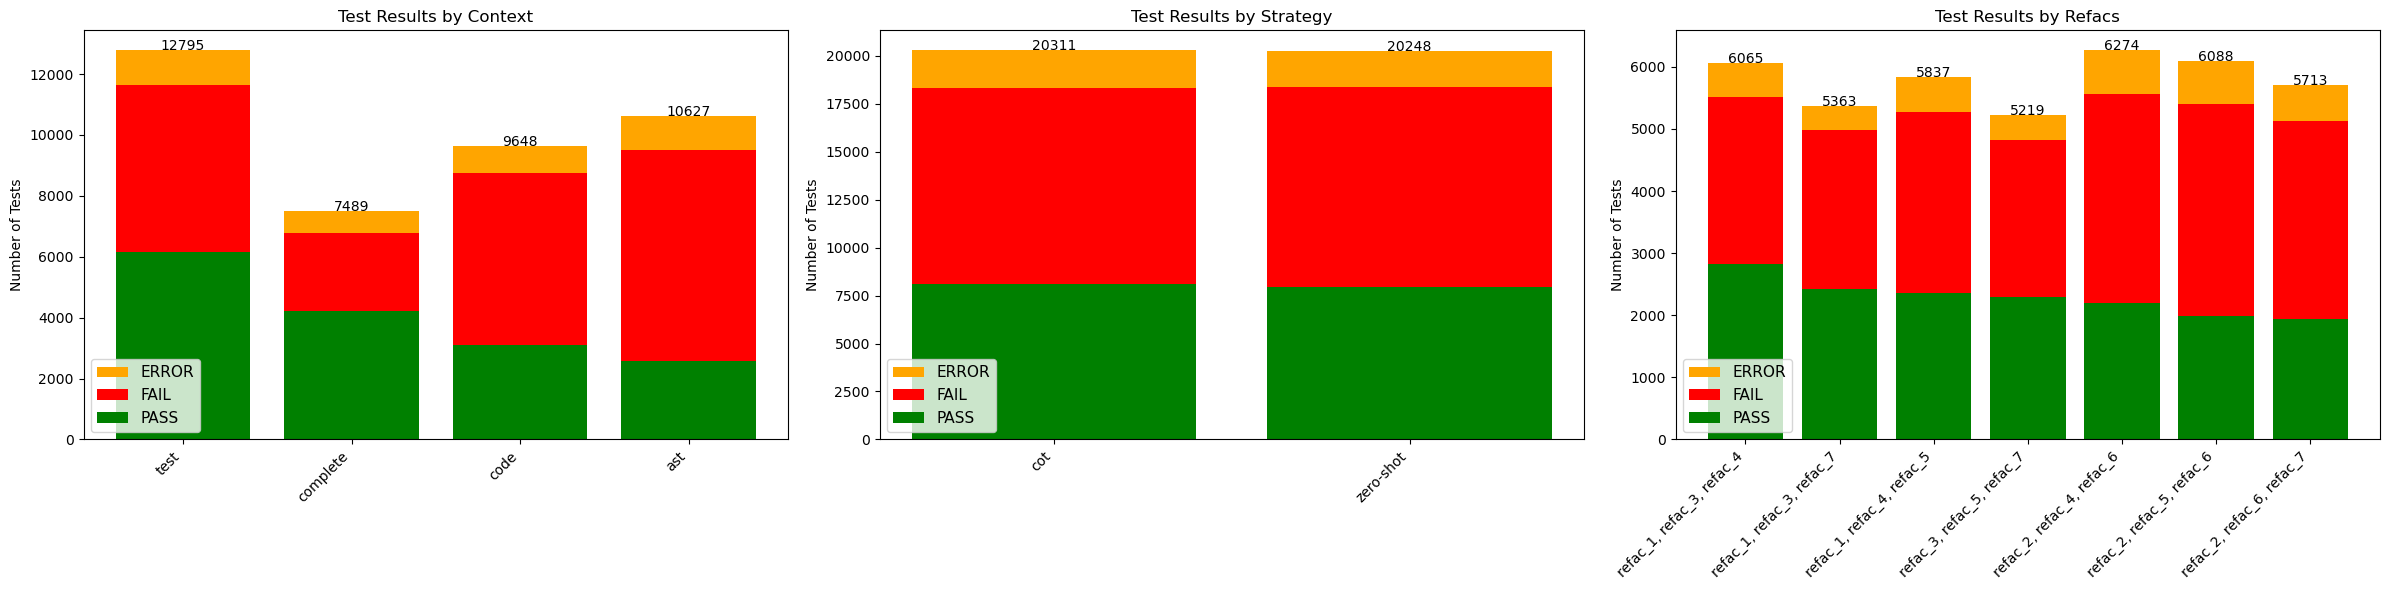

In [13]:
import json
import matplotlib.pyplot as plt

# Load dataset
with open(FILTERED_PATH_CODEBLEU, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# Initialize dictionaries for grouping
grouped_by_context = {}
grouped_by_refacs = {}
grouped_by_strategy = {}

for entry in dataset:
    # Determine expected number of tests for this entry
    if entry.get("clones"):
        num_tests = max(len(clone.get("test_results", {})) for clone in entry["clones"])
    else:
        num_tests = 0

    for clone in entry.get("clones", []):
        context = clone.get("context", "unknown")
        refacs_list = clone.get("refacs", ["unknown"])  # Correct key
        strategy = clone.get("strategy", "unknown")
        results = clone.get("test_results", {})

        # Fill missing tests as ERROR
        if len(results) < num_tests:
            missing = num_tests - len(results)
            for i in range(missing):
                results[f"missing_test_{i+1}"] = "ERROR"

        # --- Group by context ---
        grouped_by_context.setdefault(context, {"PASS": 0, "FAIL": 0, "ERROR": 0})
        for status in results.values():
            status = status.upper()
            if status in ["PASS", "FAIL", "ERROR"]:
                grouped_by_context[context][status] += 1

        # --- Group by refacs (convert list to string for dictionary key) ---
        refacs_key = ", ".join(refacs_list)
        grouped_by_refacs.setdefault(refacs_key, {"PASS": 0, "FAIL": 0, "ERROR": 0})
        for status in results.values():
            status = status.upper()
            if status in ["PASS", "FAIL", "ERROR"]:
                grouped_by_refacs[refacs_key][status] += 1

        # --- Group by strategy ---
        grouped_by_strategy.setdefault(strategy, {"PASS": 0, "FAIL": 0, "ERROR": 0})
        for status in results.values():
            status = status.upper()
            if status in ["PASS", "FAIL", "ERROR"]:
                grouped_by_strategy[strategy][status] += 1

# Function to sort and prepare data for plotting
def prepare_sorted(grouped_dict):
    # Sort by number of PASS descending
    sorted_items = sorted(grouped_dict.items(), key=lambda kv: kv[1]["PASS"], reverse=True)
    filters = [k for k, v in sorted_items]
    passes = [v["PASS"] for k, v in sorted_items]
    fails = [v["FAIL"] for k, v in sorted_items]
    errors = [v["ERROR"] for k, v in sorted_items]
    return filters, passes, fails, errors

# Prepare data
filters_context, passes_context, fails_context, errors_context = prepare_sorted(grouped_by_context)
filters_strategy, passes_strategy, fails_strategy, errors_strategy = prepare_sorted(grouped_by_strategy)
filters_refacs, passes_refacs, fails_refacs, errors_refacs = prepare_sorted(grouped_by_refacs)

# Truncate long refac labels for readability
filters_refacs = [r if len(r) <= 25 else r[:22] + "..." for r in filters_refacs]

# Create subplots (3 panels)
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# --- Plot context ---
x_context = range(len(filters_context))
axes[0].bar(x_context, passes_context, color="green", label="PASS")
axes[0].bar(x_context, fails_context, bottom=passes_context, color="red", label="FAIL")
axes[0].bar(x_context, errors_context, bottom=[p+f for p, f in zip(passes_context, fails_context)], color="orange", label="ERROR")
axes[0].set_xticks(x_context)
axes[0].set_xticklabels(filters_context, rotation=45, ha="right")
axes[0].set_ylabel("Number of Tests")
axes[0].set_title("Test Results by Context")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[::-1], labels[::-1], fontsize=11, loc="lower left")
for i, (p, f, e) in enumerate(zip(passes_context, fails_context, errors_context)):
    total = p + f + e
    axes[0].text(i, total + 2, str(total), ha="center", fontsize=10)

# --- Plot refacs ---
x_refacs = range(len(filters_refacs))
axes[2].bar(x_refacs, passes_refacs, color="green", label="PASS")
axes[2].bar(x_refacs, fails_refacs, bottom=passes_refacs, color="red", label="FAIL")
axes[2].bar(x_refacs, errors_refacs, bottom=[p+f for p, f in zip(passes_refacs, fails_refacs)], color="orange", label="ERROR")
axes[2].set_xticks(x_refacs)
axes[2].set_xticklabels(filters_refacs, rotation=45, ha="right")
axes[2].set_ylabel("Number of Tests")
axes[2].set_title("Test Results by Refacs")
handles, labels = axes[2].get_legend_handles_labels()
axes[2].legend(handles[::-1], labels[::-1], fontsize=11, loc="lower left")
for i, (p, f, e) in enumerate(zip(passes_refacs, fails_refacs, errors_refacs)):
    total = p + f + e
    axes[2].text(i, total + 2, str(total), ha="center", fontsize=10)

# --- Plot strategies ---
x_strategy = range(len(filters_strategy))
axes[1].bar(x_strategy, passes_strategy, color="green", label="PASS")
axes[1].bar(x_strategy, fails_strategy, bottom=passes_strategy, color="red", label="FAIL")
axes[1].bar(x_strategy, errors_strategy, bottom=[p+f for p, f in zip(passes_strategy, fails_strategy)], color="orange", label="ERROR")
axes[1].set_xticks(x_strategy)
axes[1].set_xticklabels(filters_strategy, rotation=45, ha="right")
axes[1].set_ylabel("Number of Tests")
axes[1].set_title("Test Results by Strategy")
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles[::-1], labels[::-1], fontsize=11, loc="lower left")
for i, (p, f, e) in enumerate(zip(passes_strategy, fails_strategy, errors_strategy)):
    total = p + f + e
    axes[1].text(i, total + 2, str(total), ha="center", fontsize=10)

plt.tight_layout()
plt.show()


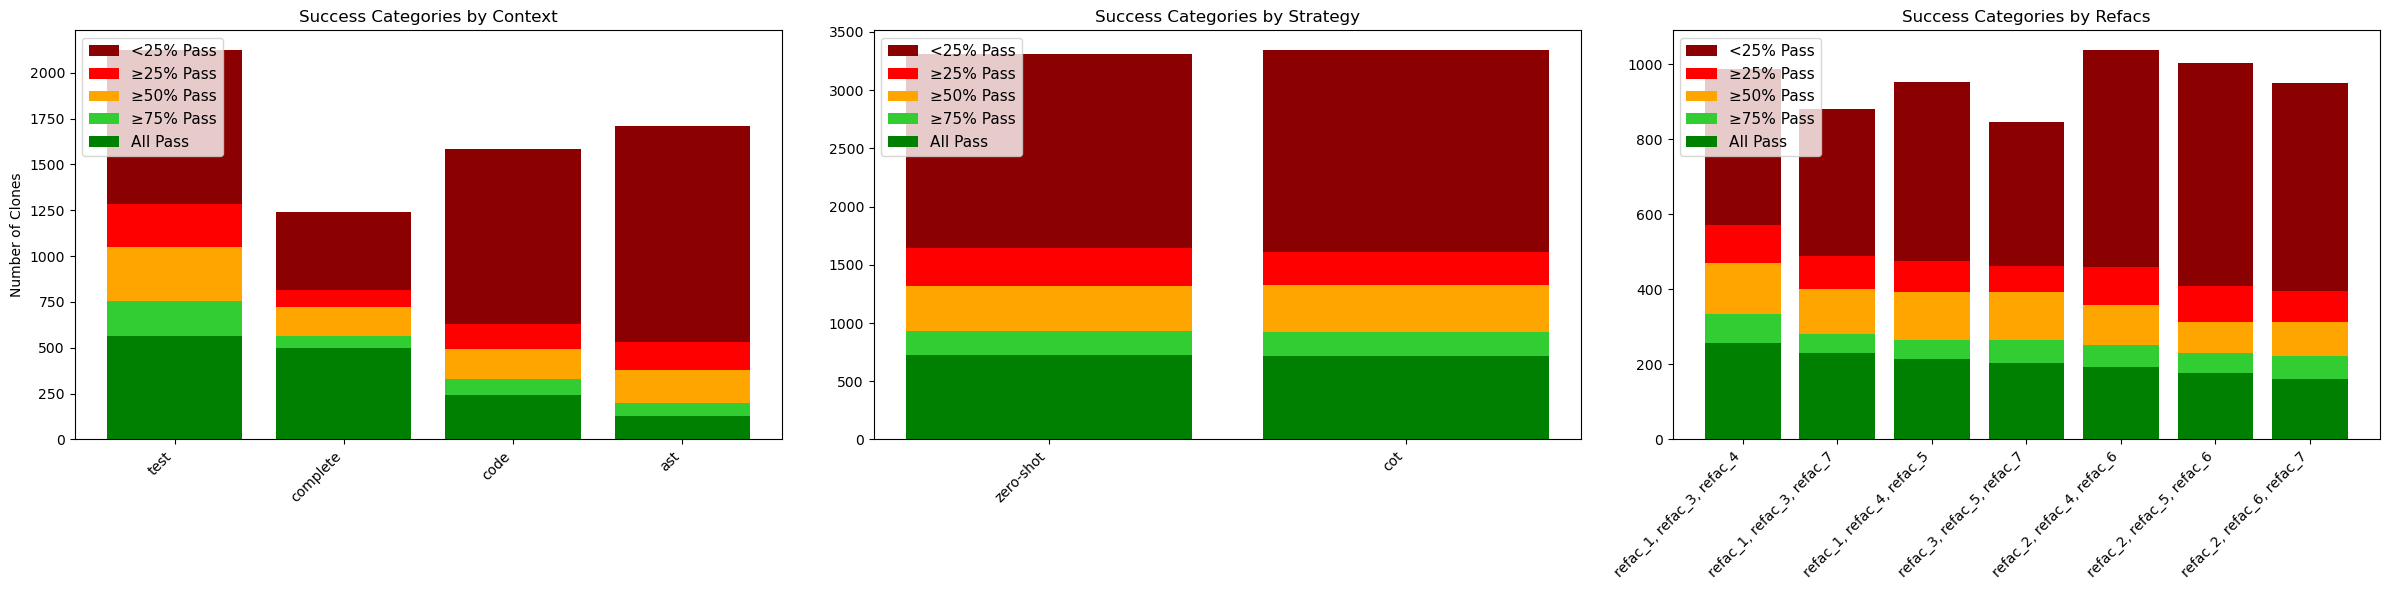

In [14]:
import json
import matplotlib.pyplot as plt

# Load dataset
with open(FILTERED_PATH_CODEBLEU, "r", encoding="utf-8") as f:
    dataset = json.load(f)

categories = ["All Pass", "≥75% Pass", "≥50% Pass", "≥25% Pass", "<25% Pass"]

def classify_clone(results, num_tests):
    num_pass = sum(1 for v in results.values() if v.upper() == "PASS")
    ratio = num_pass / num_tests if num_tests > 0 else 0

    if ratio == 1.0:
        return "All Pass"
    elif ratio >= 0.75:
        return "≥75% Pass"
    elif ratio >= 0.50:
        return "≥50% Pass"
    elif ratio >= 0.25:
        return "≥25% Pass"
    else:
        return "<25% Pass"

# Initialize grouping
grouped_context = {} 
grouped_refacs = {}
grouped_strategy = {}

for entry in dataset:
    num_tests = max((len(clone.get("test_results", {})) for clone in entry.get("clones", [])), default=0)

    for clone in entry.get("clones", []):
        context = clone.get("context", "unknown")
        refacs_list = clone.get("refacs", ["unknown"])
        strategy = clone.get("strategy", "unknown")
        results = clone.get("test_results", {})

        # Fill missing tests as ERROR
        for i in range(num_tests - len(results)):
            results[f"missing_test_{i+1}"] = "ERROR"

        category = classify_clone(results, num_tests)
        refacs_key = ", ".join(refacs_list)

        # Group by context
        grouped_context.setdefault(context, {c: 0 for c in categories})
        grouped_context[context][category] += 1

        # Group by refacs
        grouped_refacs.setdefault(refacs_key, {c: 0 for c in categories})
        grouped_refacs[refacs_key][category] += 1

        # Group by strategy
        grouped_strategy.setdefault(strategy, {c: 0 for c in categories})
        grouped_strategy[strategy][category] += 1

def plot_grouped(ax, grouped_dict, title):
    # Sort by total counts descending
    sorted_items = sorted(grouped_dict.items(), key=lambda kv: kv[1]["All Pass"], reverse=True)
    if not sorted_items:
        return  # nothing to plot

    filters, grouped_sorted = zip(*sorted_items)  # keys and dictionaries
    x = range(len(filters))
    bottoms = [0] * len(filters)

    for cat, color in zip(categories, ["green", "limegreen", "orange", "red", "darkred"]):
        values = [g[cat] for g in grouped_sorted]
        ax.bar(x, values, bottom=bottoms, label=cat, color=color)
        bottoms = [b + v for b, v in zip(bottoms, values)]

    ax.set_xticks(x)
    ax.set_xticklabels(filters, rotation=45, ha="right", fontsize=10)
    ax.set_title(title)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], fontsize=11, loc="upper left")

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

plot_grouped(axes[0], grouped_context, "Success Categories by Context") 
plot_grouped(axes[1], grouped_strategy, "Success Categories by Strategy")
plot_grouped(axes[2], grouped_refacs, "Success Categories by Refacs")

axes[0].set_ylabel("Number of Clones")

plt.tight_layout()
plt.show()


### Reprompt

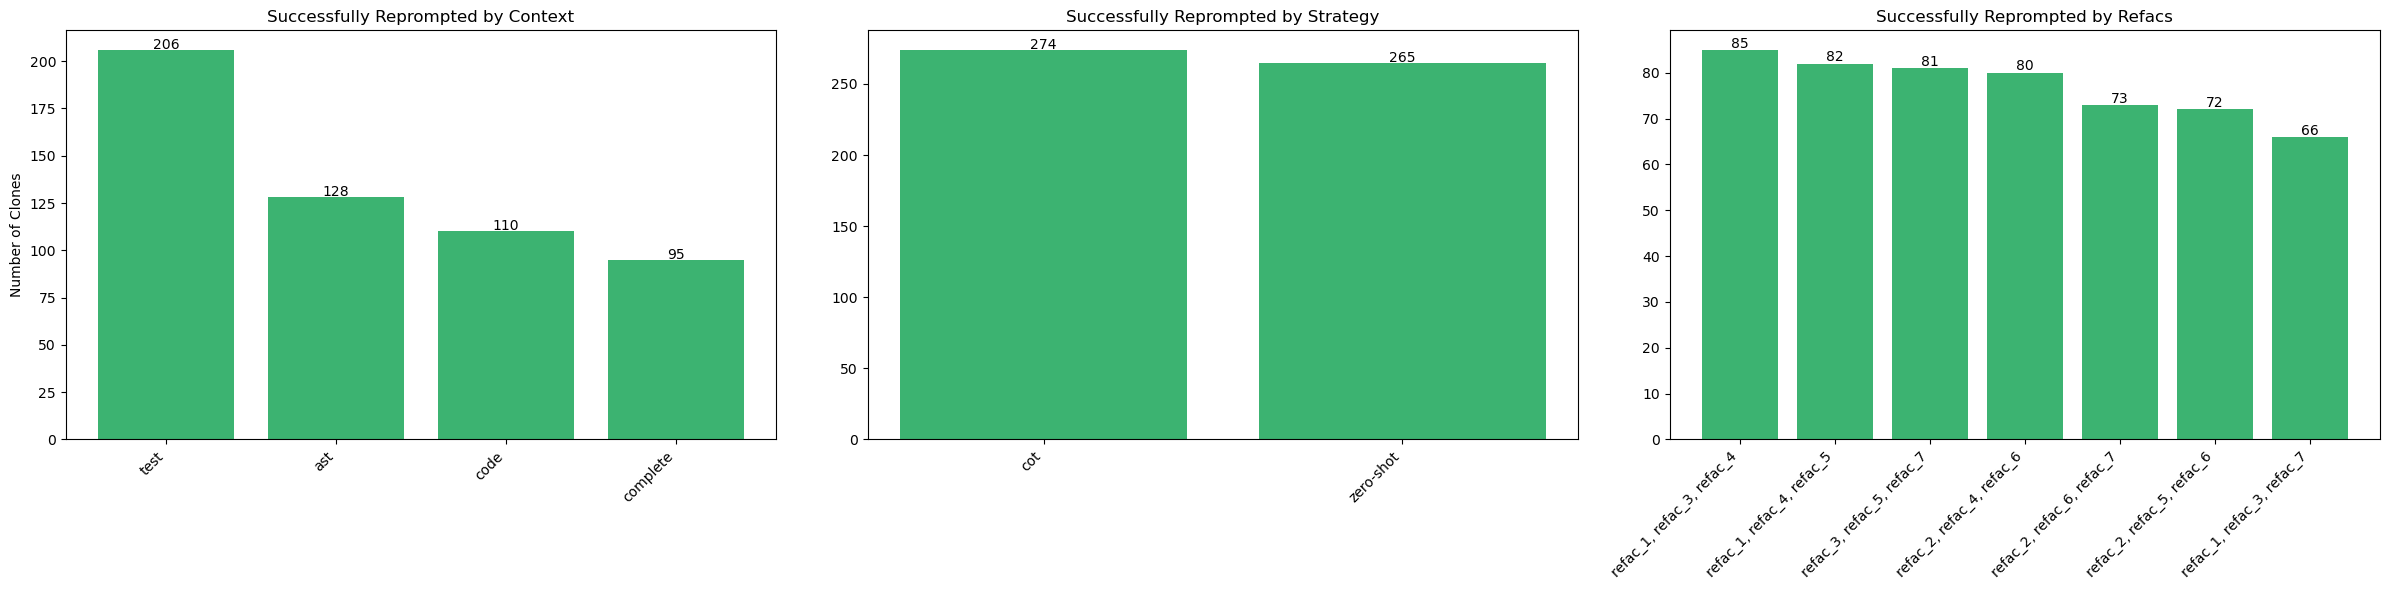

In [15]:
import json
import matplotlib.pyplot as plt

# --- Load datasets ---
with open(FILTERED_PATH_CODEBLEU, "r", encoding="utf-8") as f:
    before_data = json.load(f)

with open(REPROMPT_PATH, "r", encoding="utf-8") as f:
    after_data = json.load(f)

# --- Index clones by (entry_id, clone_id) ---
def index_clones(dataset):
    index = {}
    for entry in dataset:
        entry_id = entry.get("id")
        for clone in entry.get("clones", []):
            clone_id = clone.get("clone_id")
            index[(entry_id, clone_id)] = clone
    return index

before_index = index_clones(before_data)
after_index = index_clones(after_data)

# --- Category ---
categories = ["Successfully Reprompted"]

# --- Initialize grouping dicts ---
grouped_context = {}
grouped_refacs = {}
grouped_strategy = {}

for key, before_clone in before_index.items():
    after_clone = after_index.get(key)
    if not after_clone:
        continue  # skip clones not reprompted

    before_results = before_clone.get("test_results", {})
    after_results  = after_clone.get("test_results", {})

    # Count number of passing tests
    before_pass = sum(1 for r in before_results.values() if isinstance(r, str) and r.upper() == "PASS")
    after_pass  = sum(1 for r in after_results.values()  if isinstance(r, str) and r.upper() == "PASS")

    improved = after_pass > before_pass
    if not improved:
        continue  # only count successfully reprompted clones

    context = after_clone.get("context", "unknown")
    strategy = after_clone.get("strategy", "unknown")
    refacs_list = after_clone.get("refacs", ["unknown"])
    refacs_key = ", ".join(refacs_list)

    # Group by context
    grouped_context[context] = grouped_context.get(context, 0) + 1
    # Group by strategy
    grouped_strategy[strategy] = grouped_strategy.get(strategy, 0) + 1
    # Group by refacs
    grouped_refacs[refacs_key] = grouped_refacs.get(refacs_key, 0) + 1

# --- Plotting function with descending order ---
def plot_grouped(ax, grouped_dict, title):
    # Sort descending
    sorted_items = sorted(grouped_dict.items(), key=lambda x: x[1], reverse=True)
    filters, values = zip(*sorted_items) if sorted_items else ([], [])

    x = range(len(filters))
    ax.bar(x, values, color="mediumseagreen")
    ax.set_xticks(x)
    ax.set_xticklabels(filters, rotation=45, ha="right", fontsize=10)
    ax.set_title(title)
    for i, v in enumerate(values):
        ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)

# --- Create subplots ---
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

plot_grouped(axes[0], grouped_context, "Successfully Reprompted by Context")
plot_grouped(axes[1], grouped_strategy, "Successfully Reprompted by Strategy")
plot_grouped(axes[2], grouped_refacs, "Successfully Reprompted by Refacs")

axes[0].set_ylabel("Number of Clones")
plt.tight_layout()
plt.show()


## Per LLM

### Codebleu

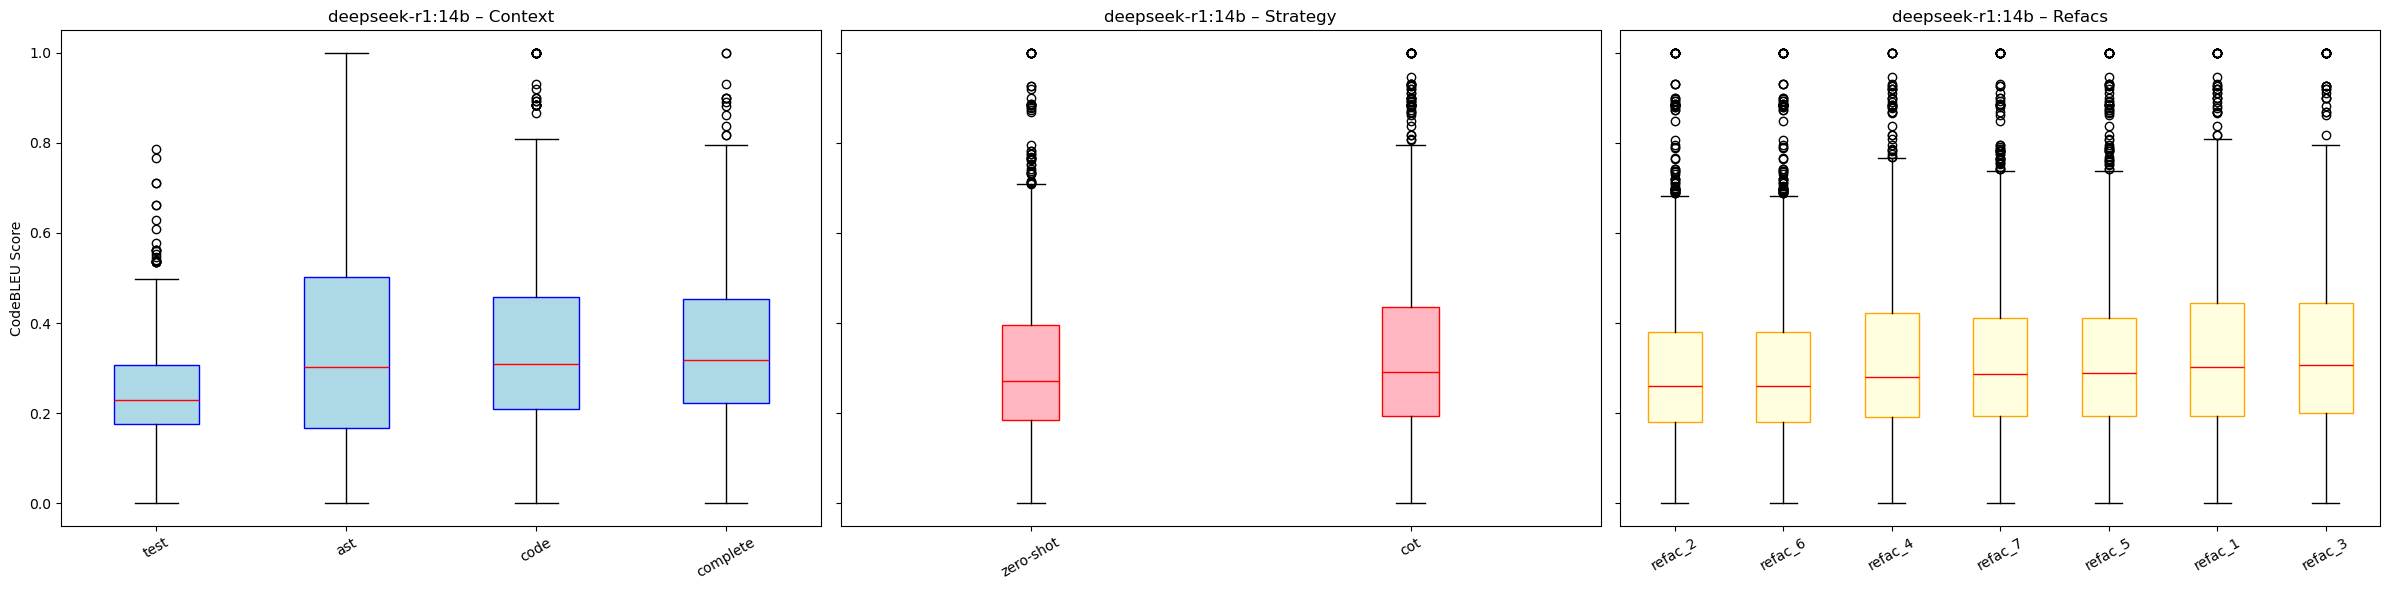

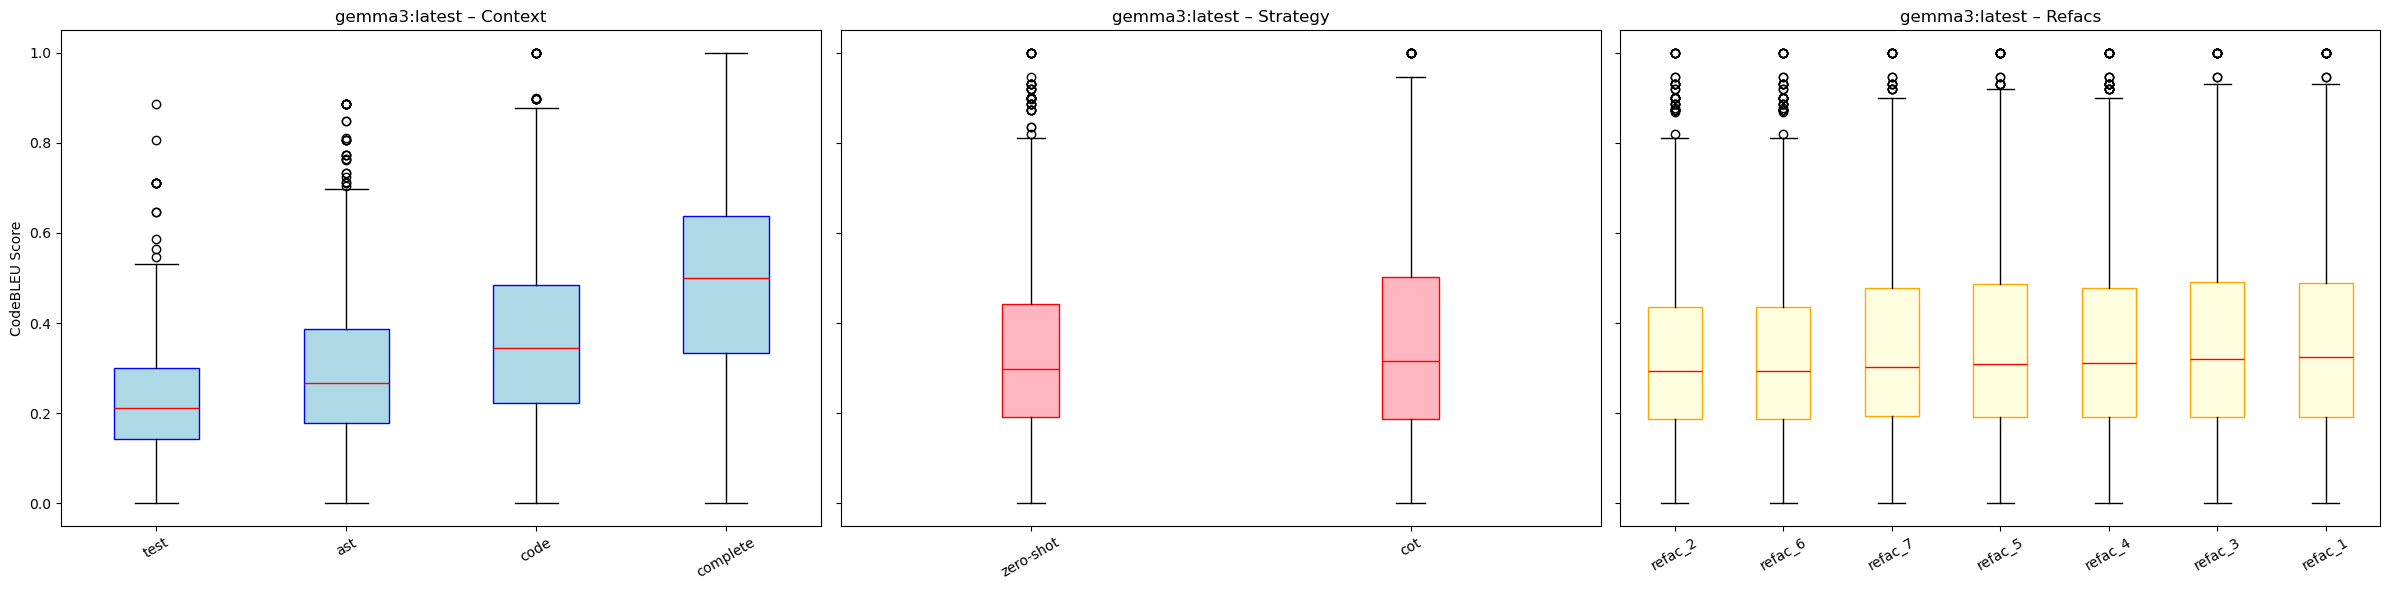

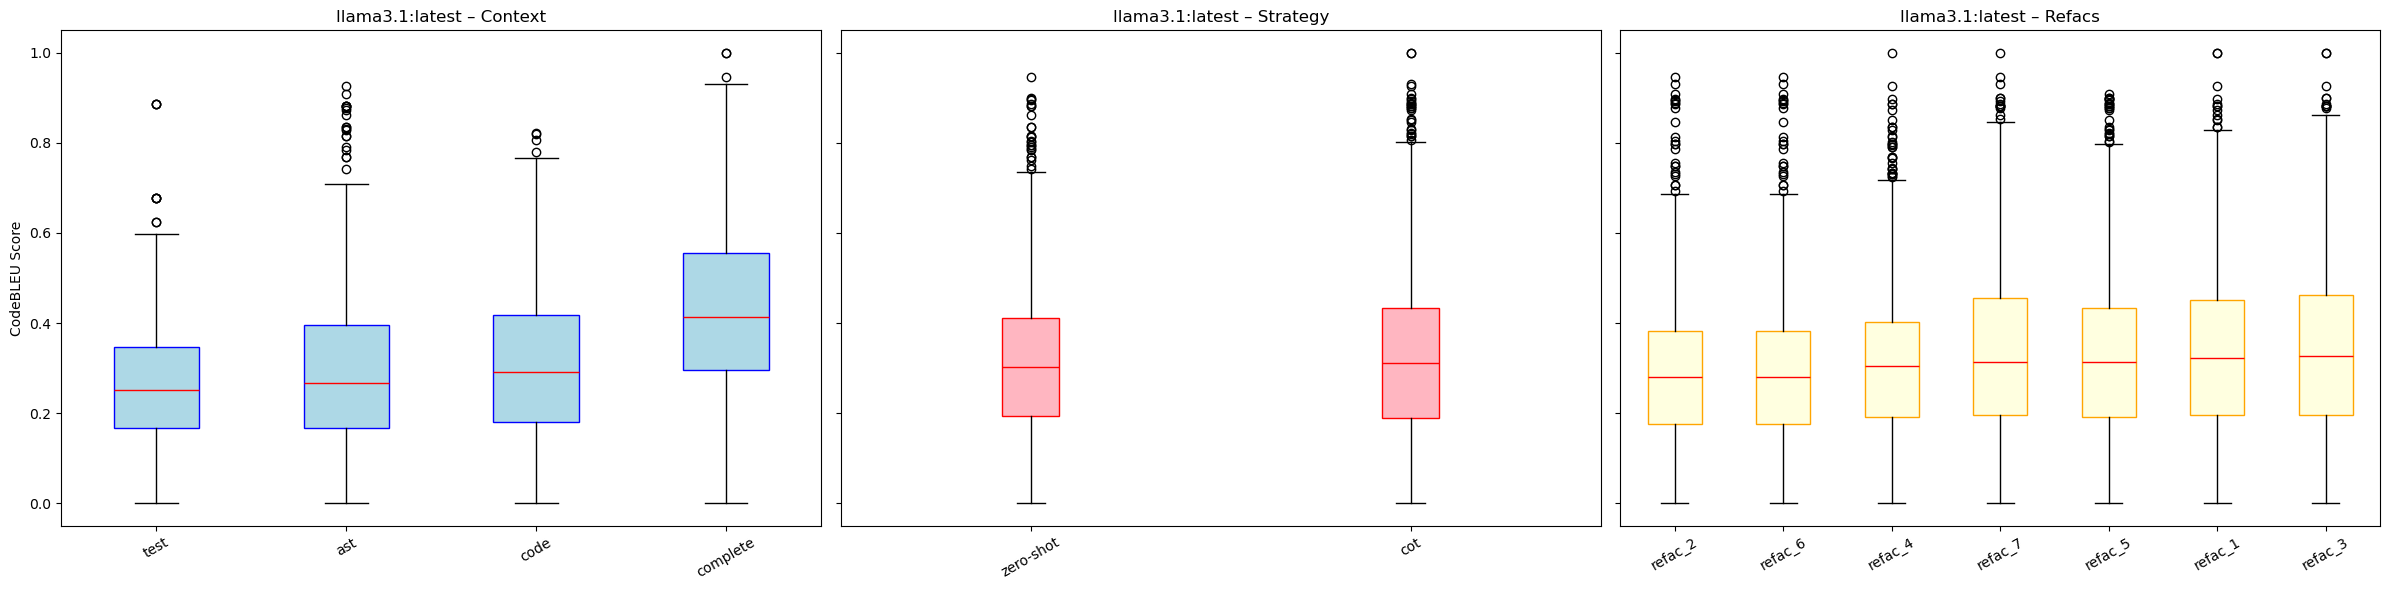

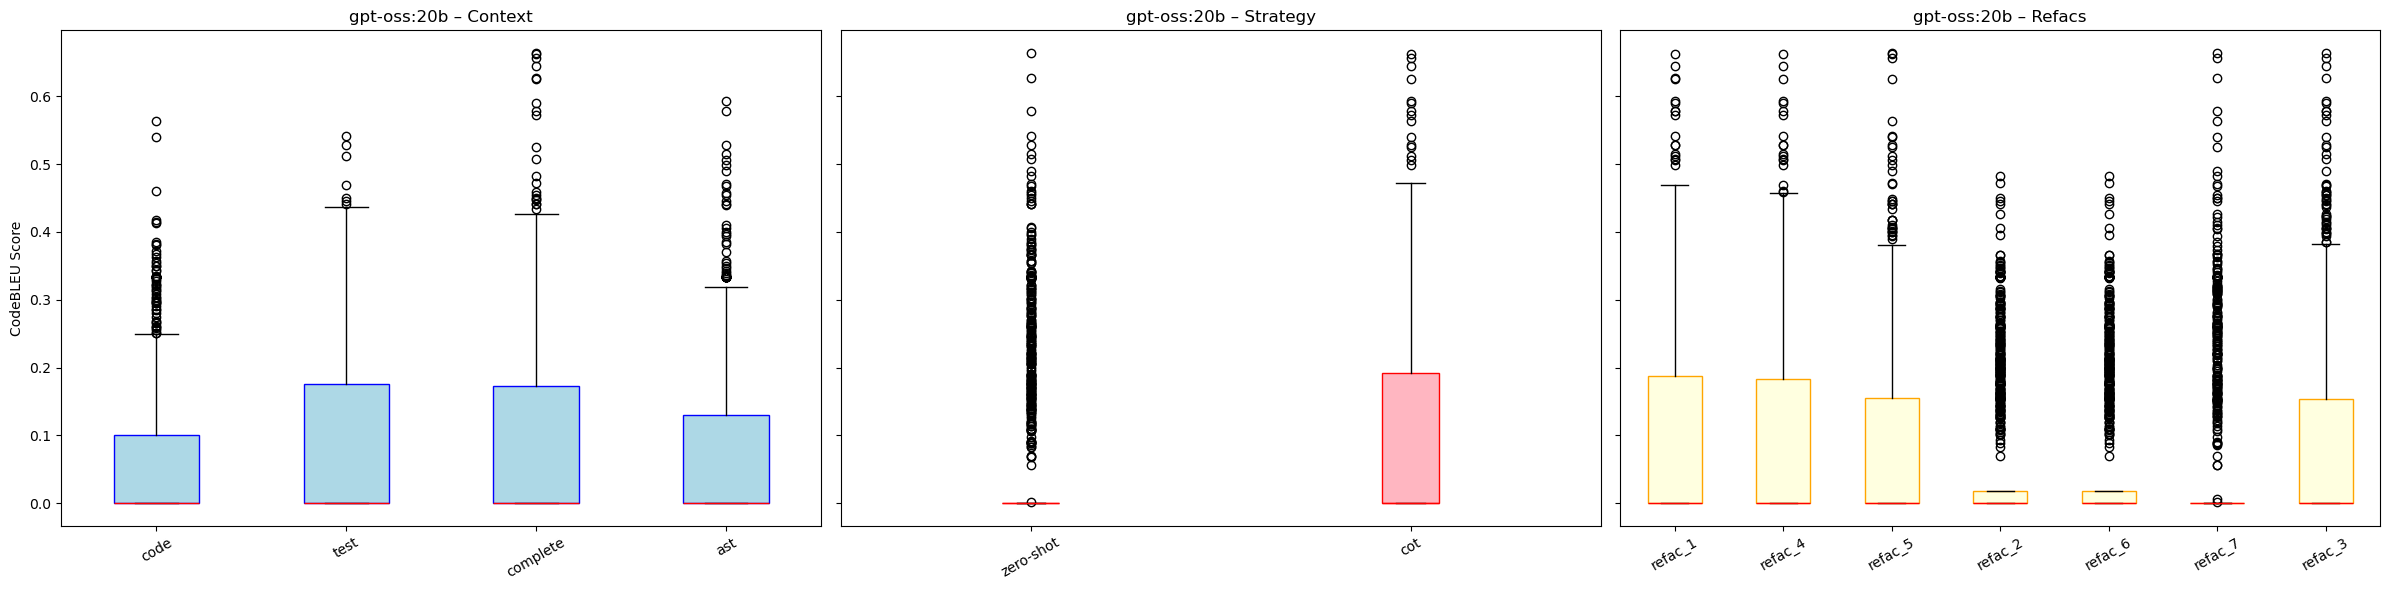

In [16]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# Collect CodeBLEU scores per model → per context/strategy/refac
scores_by_model = {}

for entry in dataset:
    for clone in entry.get("clones", []):
        model = clone.get("model", "unknown")
        context = clone.get("context", "unknown")
        strategy = clone.get("strategy", "unknown")  
        score_dict = clone.get("metrics", {}).get("codebleu", {})
        score = score_dict.get("originalcode") 

        if score is not None:
            model_dict = scores_by_model.setdefault(model, {"context": {}, "strategy": {}, "refacs": {}})
            model_dict["context"].setdefault(context, []).append(score)
            model_dict["strategy"].setdefault(strategy, []).append(score)

            # --- Handle individual refacs ---
            refacs = clone.get("refacs", [])
            if isinstance(refacs, list):
                for ref in refacs:
                    model_dict["refacs"].setdefault(ref, []).append(score)
            elif isinstance(refacs, str):
                model_dict["refacs"].setdefault(refacs, []).append(score)

# Generate boxplots per model
for model, grouped in scores_by_model.items():
    scores_by_context = grouped["context"]
    scores_by_strategy = grouped["strategy"]
    scores_by_refacs = grouped["refacs"]

    fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)

    # --- Context boxplot ---
    labels_context, data_context = zip(*sorted(
        ((c, scores_by_context[c]) for c in scores_by_context),
        key=lambda x: np.median(x[1])
    ))
    axes[0].boxplot(data_context, vert=True, patch_artist=True,
                    labels=labels_context,
                    boxprops=dict(facecolor="lightblue", color="blue"),
                    medianprops=dict(color="red"))
    axes[0].set_title(f"{model} – Context")
    axes[0].tick_params(axis="x", rotation=30)

    # --- Strategy boxplot ---
    labels_strat, data_strat = zip(*sorted(
        ((s, scores_by_strategy[s]) for s in scores_by_strategy),
        key=lambda x: np.median(x[1])
    ))
    axes[1].boxplot(data_strat, vert=True, patch_artist=True,
                    labels=labels_strat,
                    boxprops=dict(facecolor="lightpink", color="red"),
                    medianprops=dict(color="red"))
    axes[1].set_title(f"{model} – Strategy")
    axes[1].tick_params(axis="x", rotation=30)

    # --- Refacs boxplot ---
    labels_refacs, data_refacs = zip(*sorted(
        ((r, scores_by_refacs[r]) for r in scores_by_refacs),
        key=lambda x: np.median(x[1])
    ))
    axes[2].boxplot(data_refacs, vert=True, patch_artist=True,
                    labels=labels_refacs,
                    boxprops=dict(facecolor="lightyellow", color="orange"),
                    medianprops=dict(color="red"))
    axes[2].set_title(f"{model} – Refacs")
    axes[2].tick_params(axis="x", rotation=30)

    axes[0].set_ylabel("CodeBLEU Score")
    plt.tight_layout()
    plt.show()


### Tests

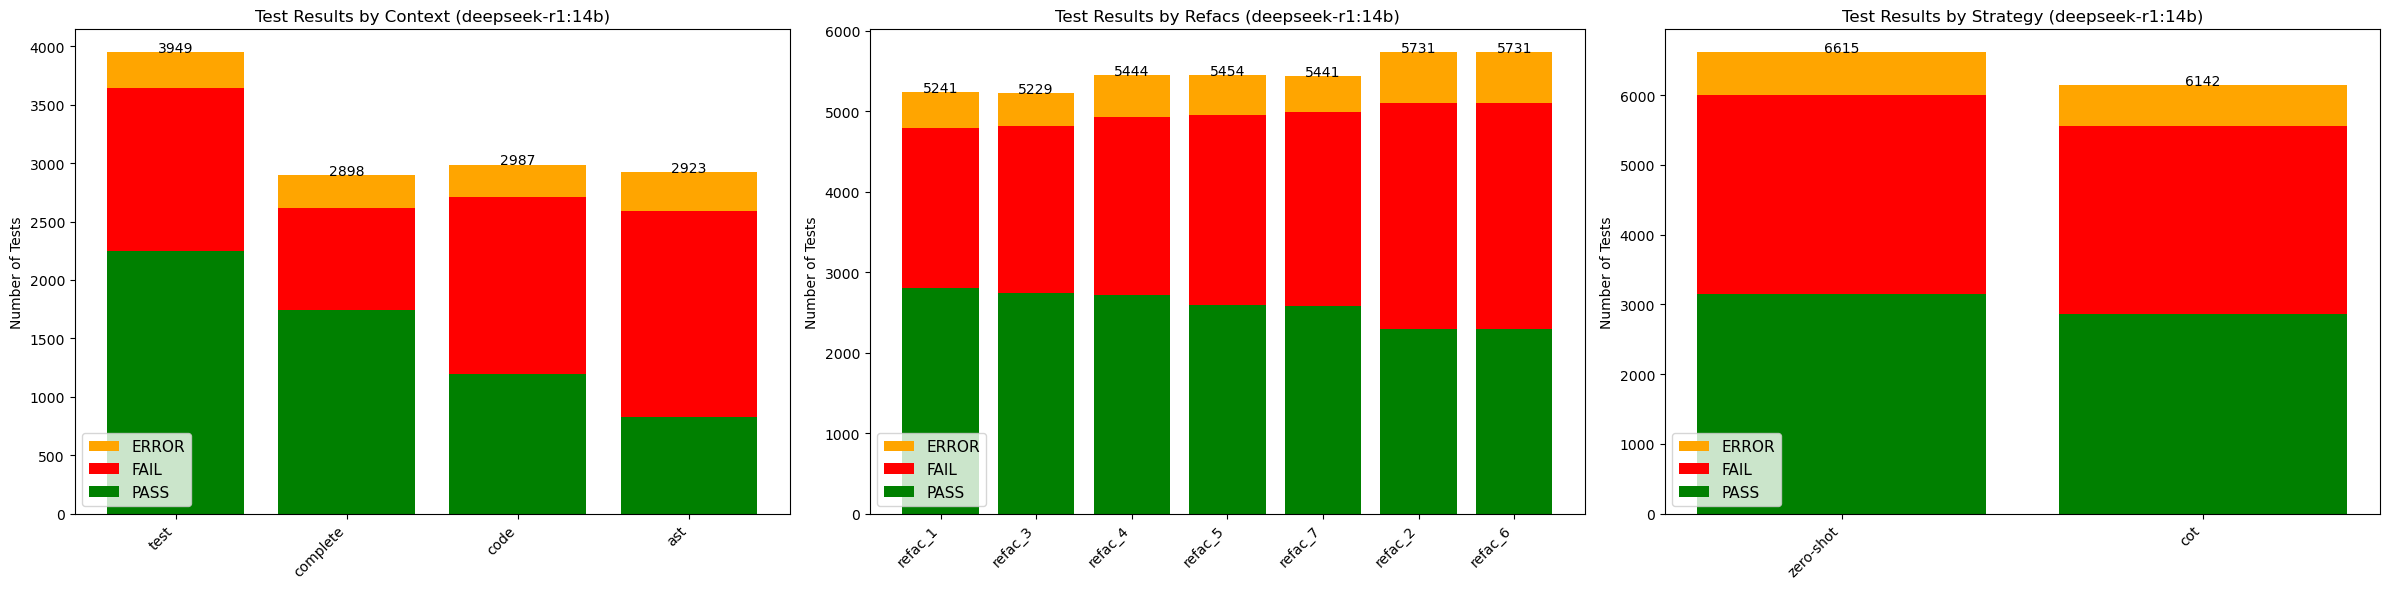

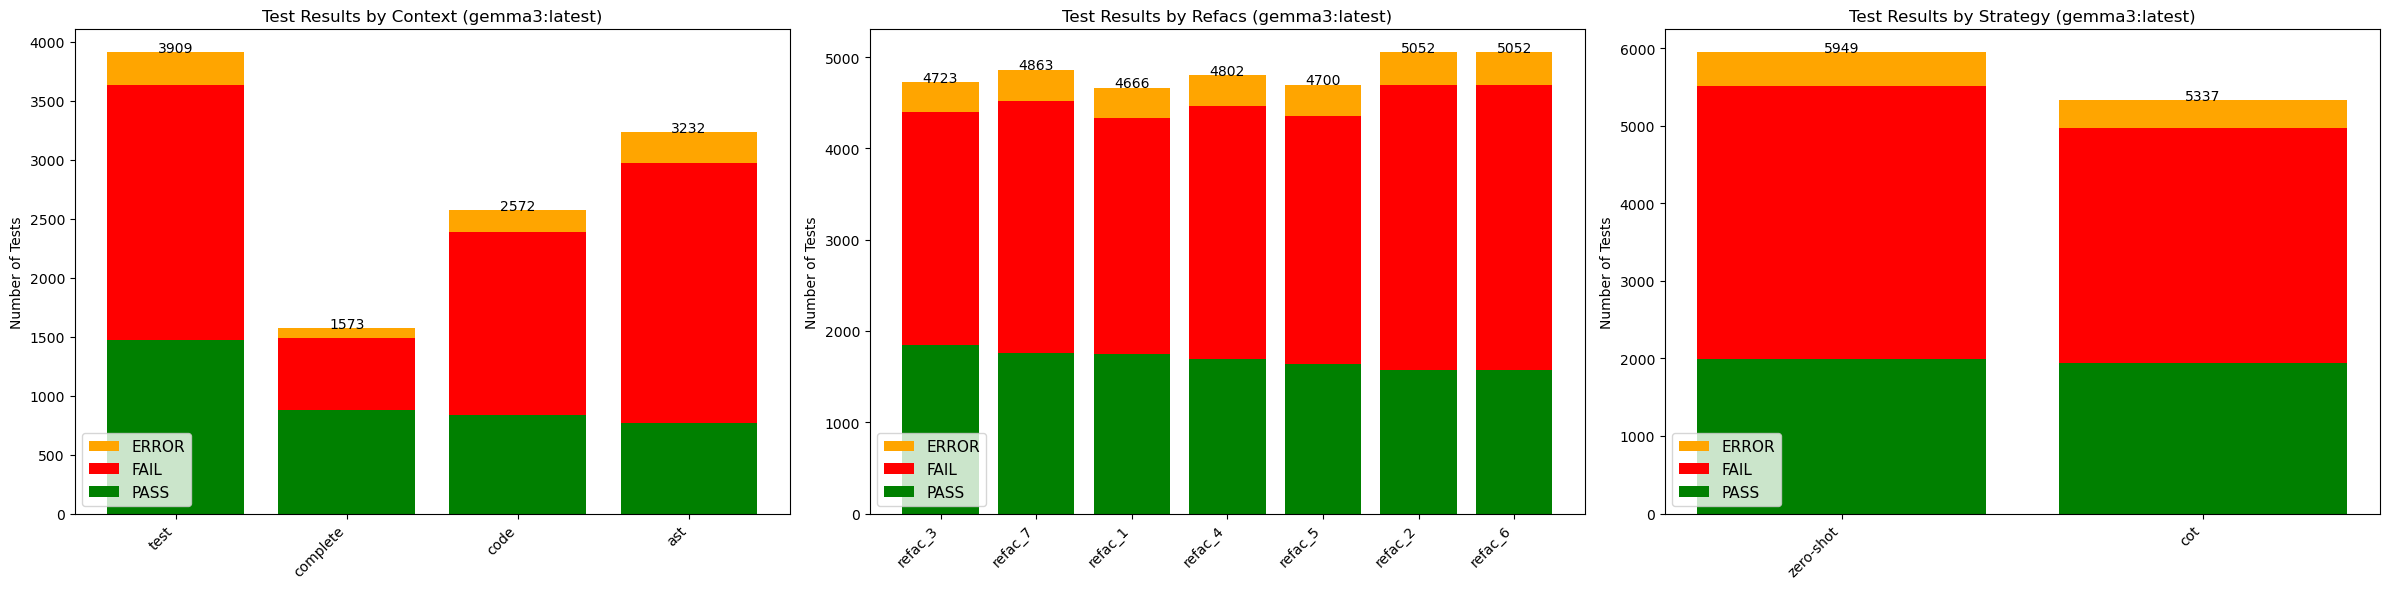

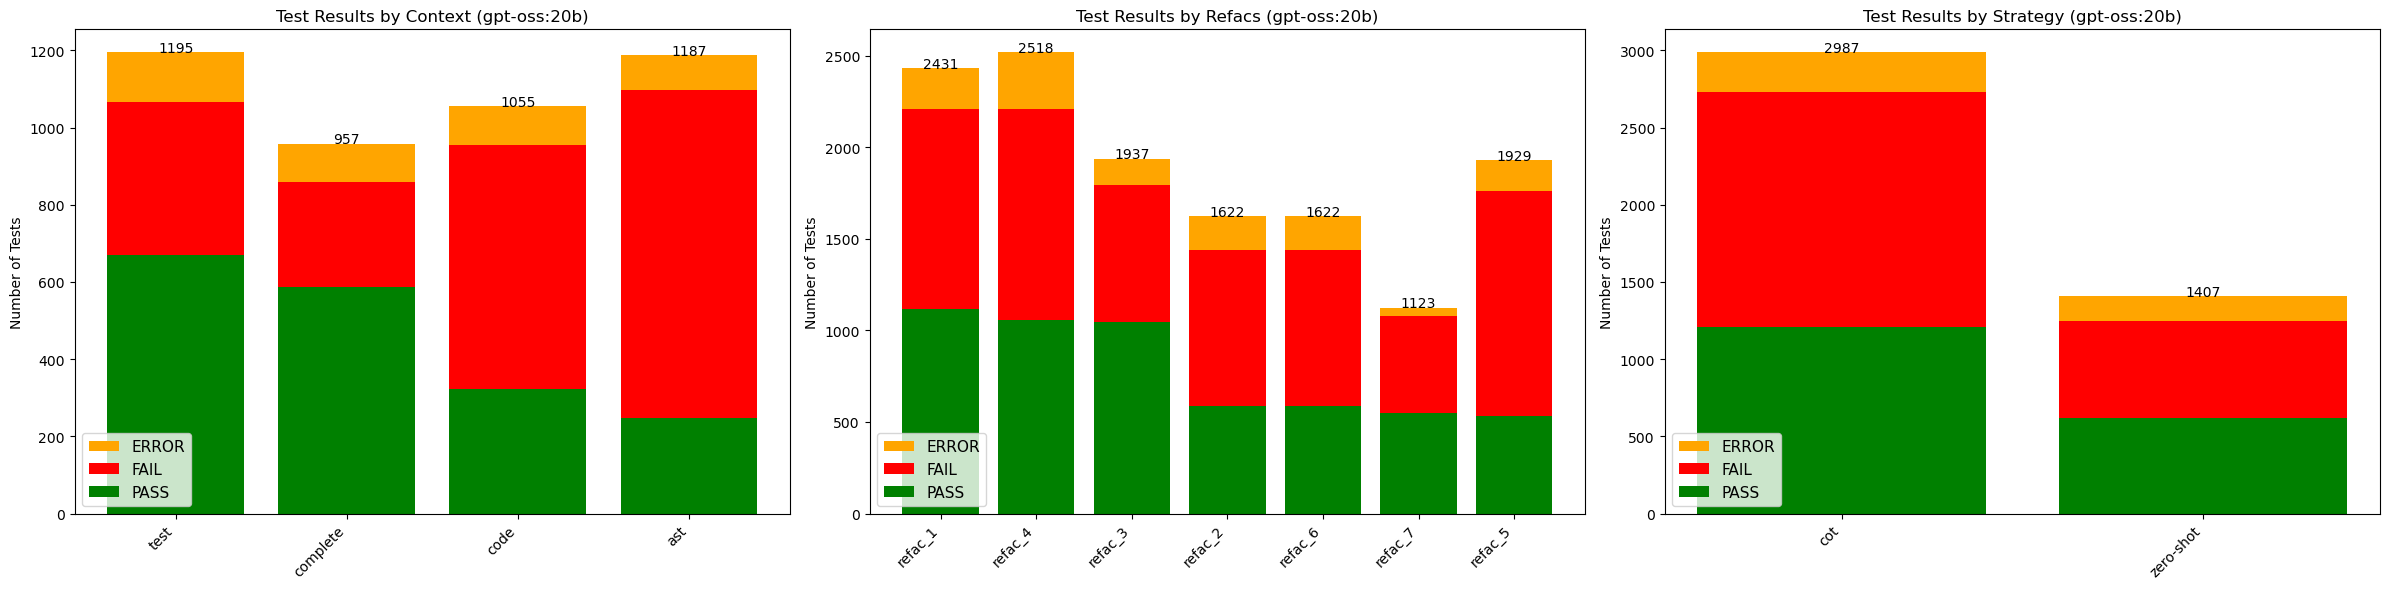

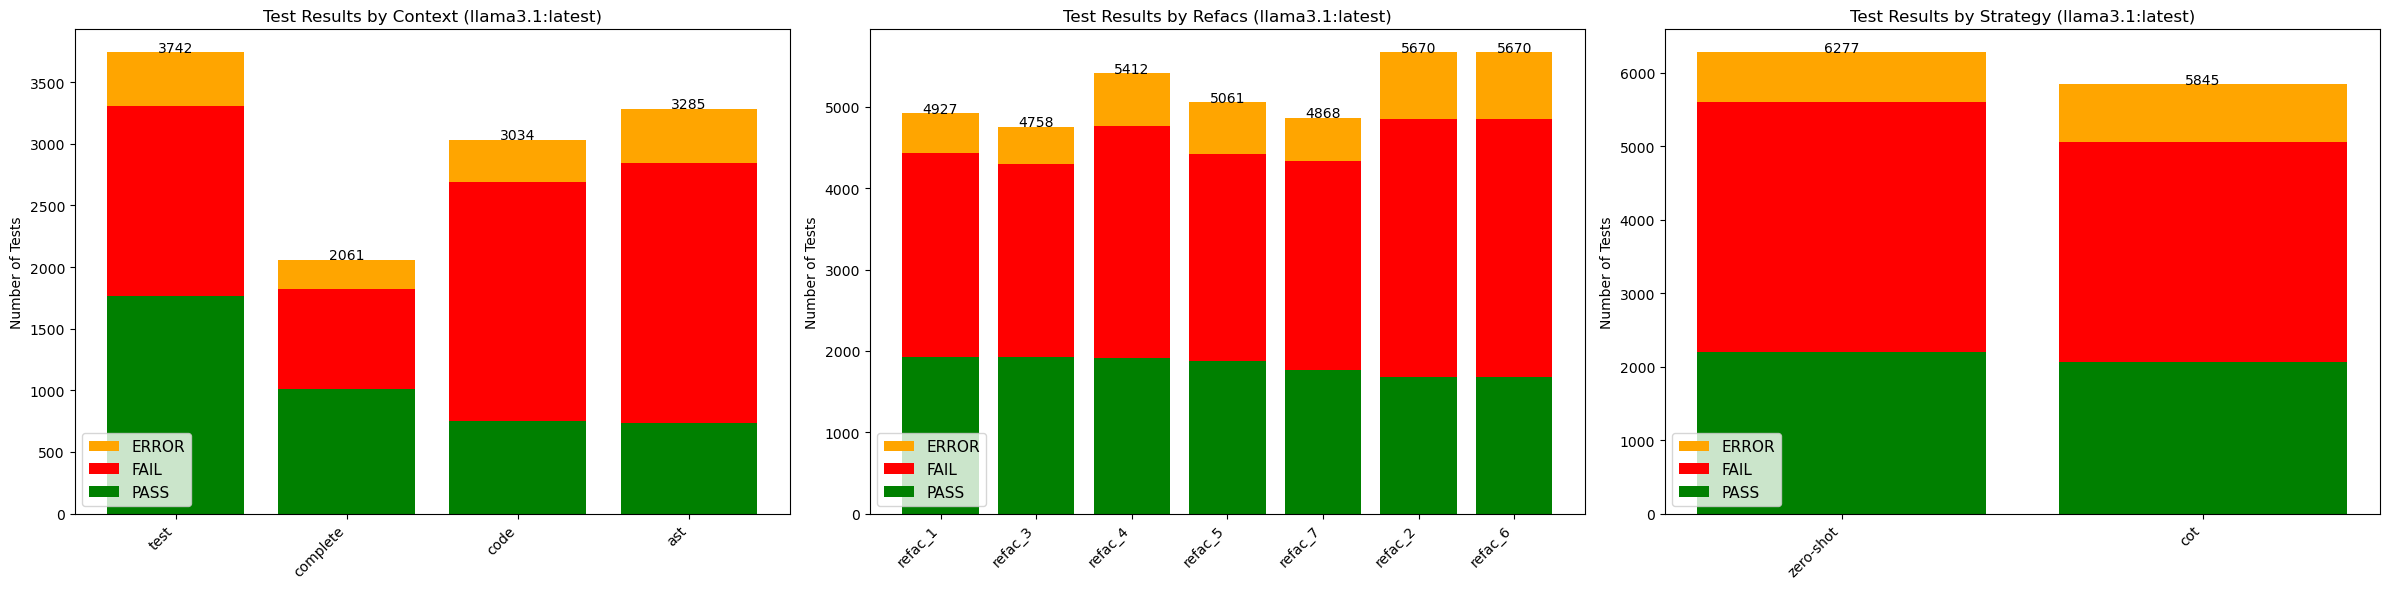

In [17]:
import json
import matplotlib.pyplot as plt

# Load dataset
with open(FILTERED_PATH_CODEBLEU, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# Identify models
models = set()
for entry in dataset:
    for clone in entry.get("clones", []):
        models.add(clone.get("model", "unknown"))
models = sorted(models)

for model in models:
    grouped_by_context = {}
    grouped_by_refacs = {}
    grouped_by_strategy = {}

    for entry in dataset:
        # Determine expected number of tests
        if entry.get("clones"):
            num_tests = max(len(clone.get("test_results", {})) for clone in entry["clones"])
        else:
            num_tests = 0

        for clone in entry.get("clones", []):
            if clone.get("model") != model:
                continue

            context = clone.get("context", "unknown")
            strategy = clone.get("strategy", "unknown")
            refacs_list = clone.get("refacs", ["unknown"])
            results = clone.get("test_results", {})

            # Fill missing tests as ERROR
            if len(results) < num_tests:
                for i in range(num_tests - len(results)):
                    results[f"missing_test_{i+1}"] = "ERROR"

            # --- Group by context ---
            grouped_by_context.setdefault(context, {"PASS": 0, "FAIL": 0, "ERROR": 0})
            for status in results.values():
                status = status.upper()
                if status in ["PASS", "FAIL", "ERROR"]:
                    grouped_by_context[context][status] += 1

            # --- Group by refacs individually ---
            for refac in refacs_list:
                grouped_by_refacs.setdefault(refac, {"PASS": 0, "FAIL": 0, "ERROR": 0})
                for status in results.values():
                    status = status.upper()
                    if status in ["PASS", "FAIL", "ERROR"]:
                        grouped_by_refacs[refac][status] += 1

            # --- Group by strategy ---
            grouped_by_strategy.setdefault(strategy, {"PASS": 0, "FAIL": 0, "ERROR": 0})
            for status in results.values():
                status = status.upper()
                if status in ["PASS", "FAIL", "ERROR"]:
                    grouped_by_strategy[strategy][status] += 1

    # Helper function to prepare sorted data
    def prepare_data_sorted(grouped_dict):
        # Sort by number of passed tests ascending
        sorted_items = sorted(grouped_dict.items(), key=lambda x: x[1]["PASS"], reverse=True)
        filters = [k for k, _ in sorted_items]
        passes = [v["PASS"] for _, v in sorted_items]
        fails  = [v["FAIL"] for _, v in sorted_items]
        errors = [v["ERROR"] for _, v in sorted_items]
        return filters, passes, fails, errors

    # Prepare data
    filters_context, passes_context, fails_context, errors_context = prepare_data_sorted(grouped_by_context)
    filters_refacs, passes_refacs, fails_refacs, errors_refacs = prepare_data_sorted(grouped_by_refacs)
    filters_strategy, passes_strategy, fails_strategy, errors_strategy = prepare_data_sorted(grouped_by_strategy)

    # Create subplots (3 panels)
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))

    def plot_panel(ax, labels, passes, fails, errors, title):
        x = range(len(labels))
        ax.bar(x, passes, color="green", label="PASS")
        ax.bar(x, fails, bottom=passes, color="red", label="FAIL")
        ax.bar(x, errors, bottom=[p+f for p,f in zip(passes, fails)], color="orange", label="ERROR")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_ylabel("Number of Tests")
        ax.set_title(title)
        handles, labels_legend = ax.get_legend_handles_labels()
        ax.legend(handles[::-1], labels_legend[::-1], fontsize=11, loc="lower left")
        for i, (p,f,e) in enumerate(zip(passes, fails, errors)):
            total = p+f+e
            ax.text(i, total+2, str(total), ha="center", fontsize=10)

    plot_panel(axes[0], filters_context, passes_context, fails_context, errors_context, f"Test Results by Context ({model})")
    plot_panel(axes[1], filters_refacs, passes_refacs, fails_refacs, errors_refacs, f"Test Results by Refacs ({model})")
    plot_panel(axes[2], filters_strategy, passes_strategy, fails_strategy, errors_strategy, f"Test Results by Strategy ({model})")

    plt.tight_layout()
    plt.show()


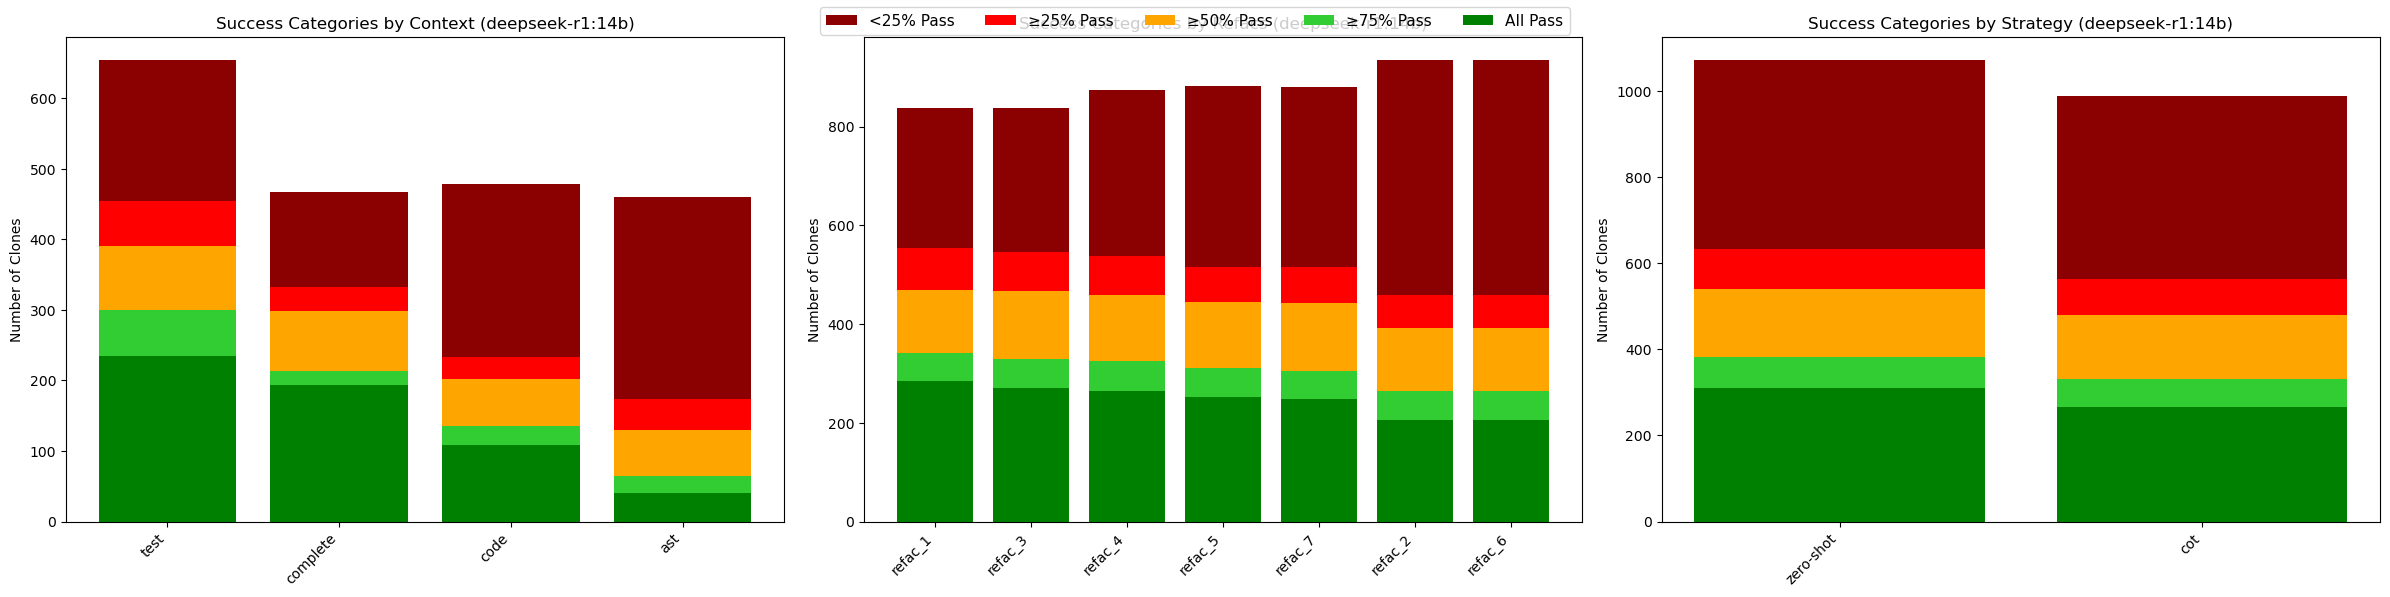

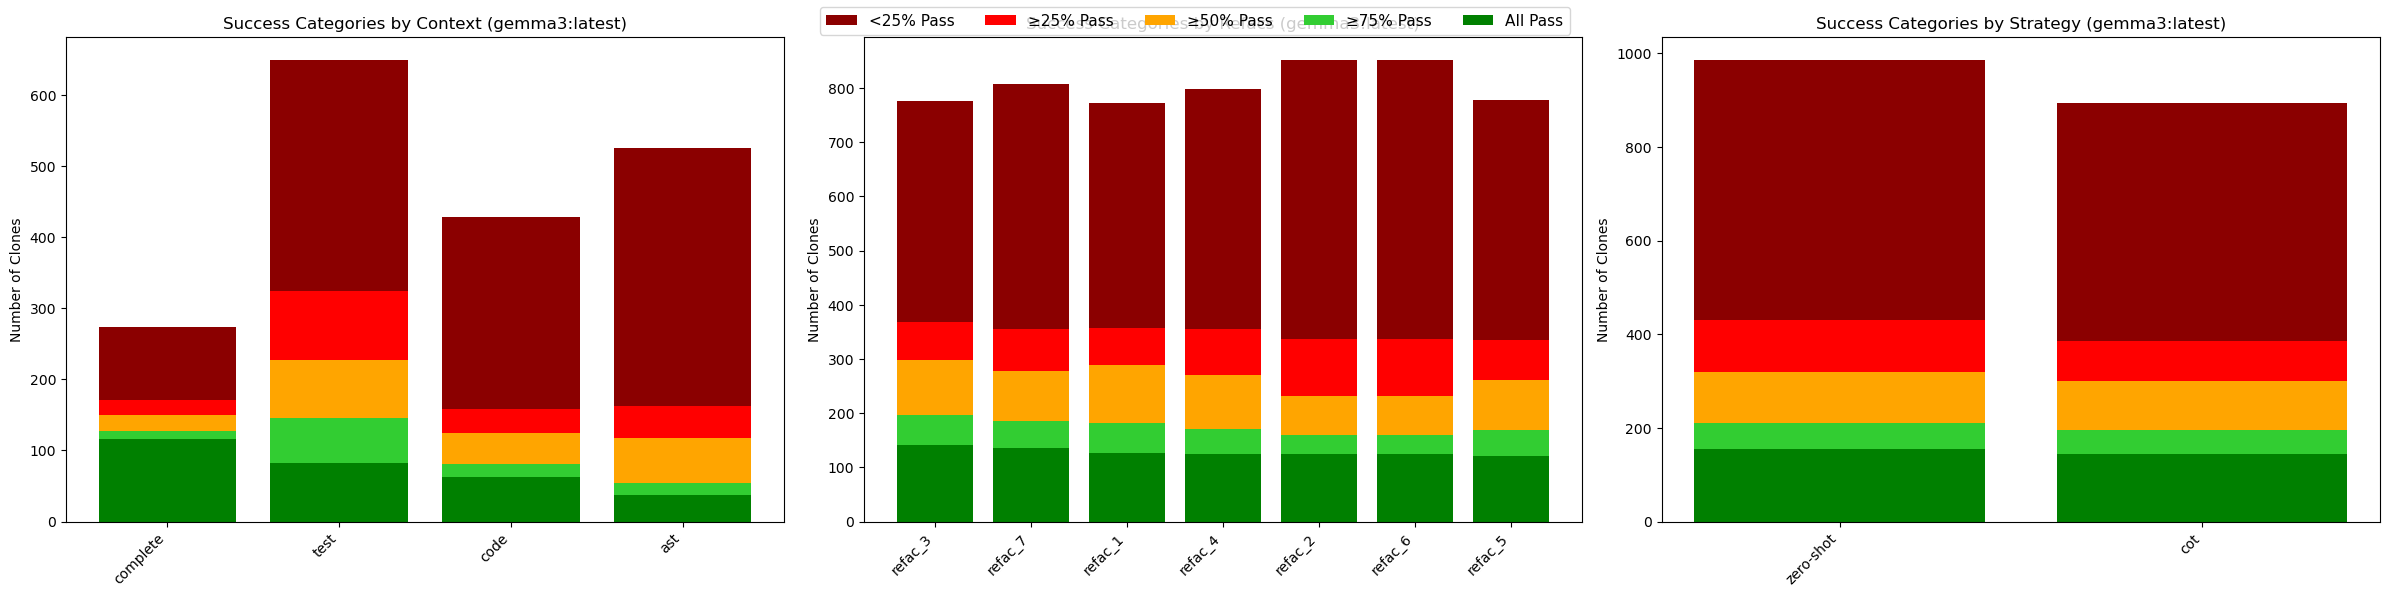

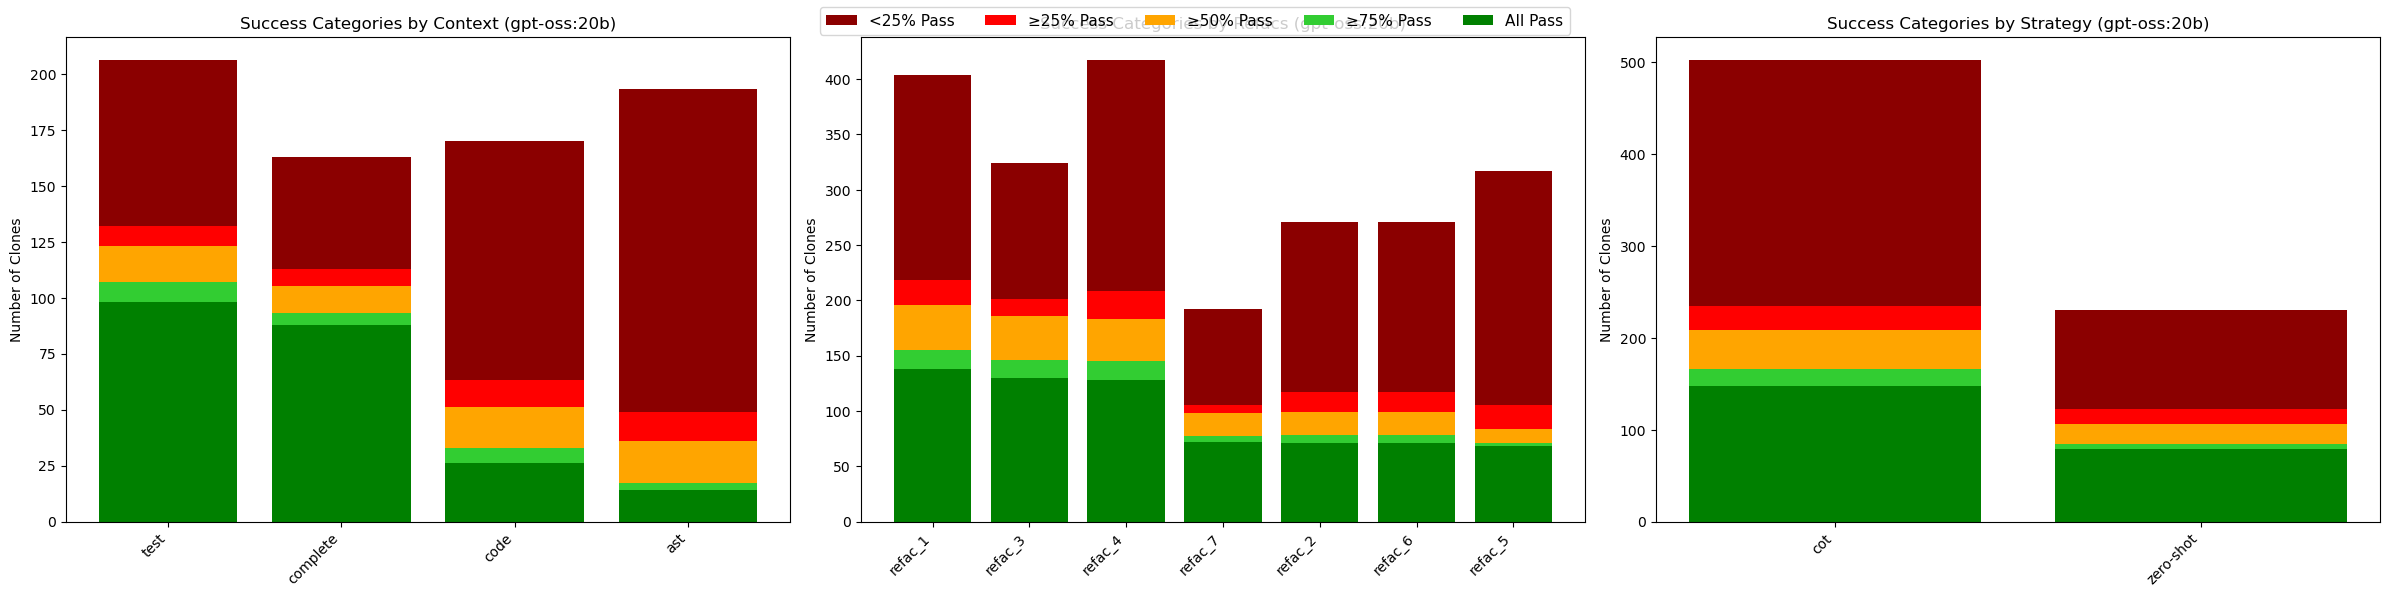

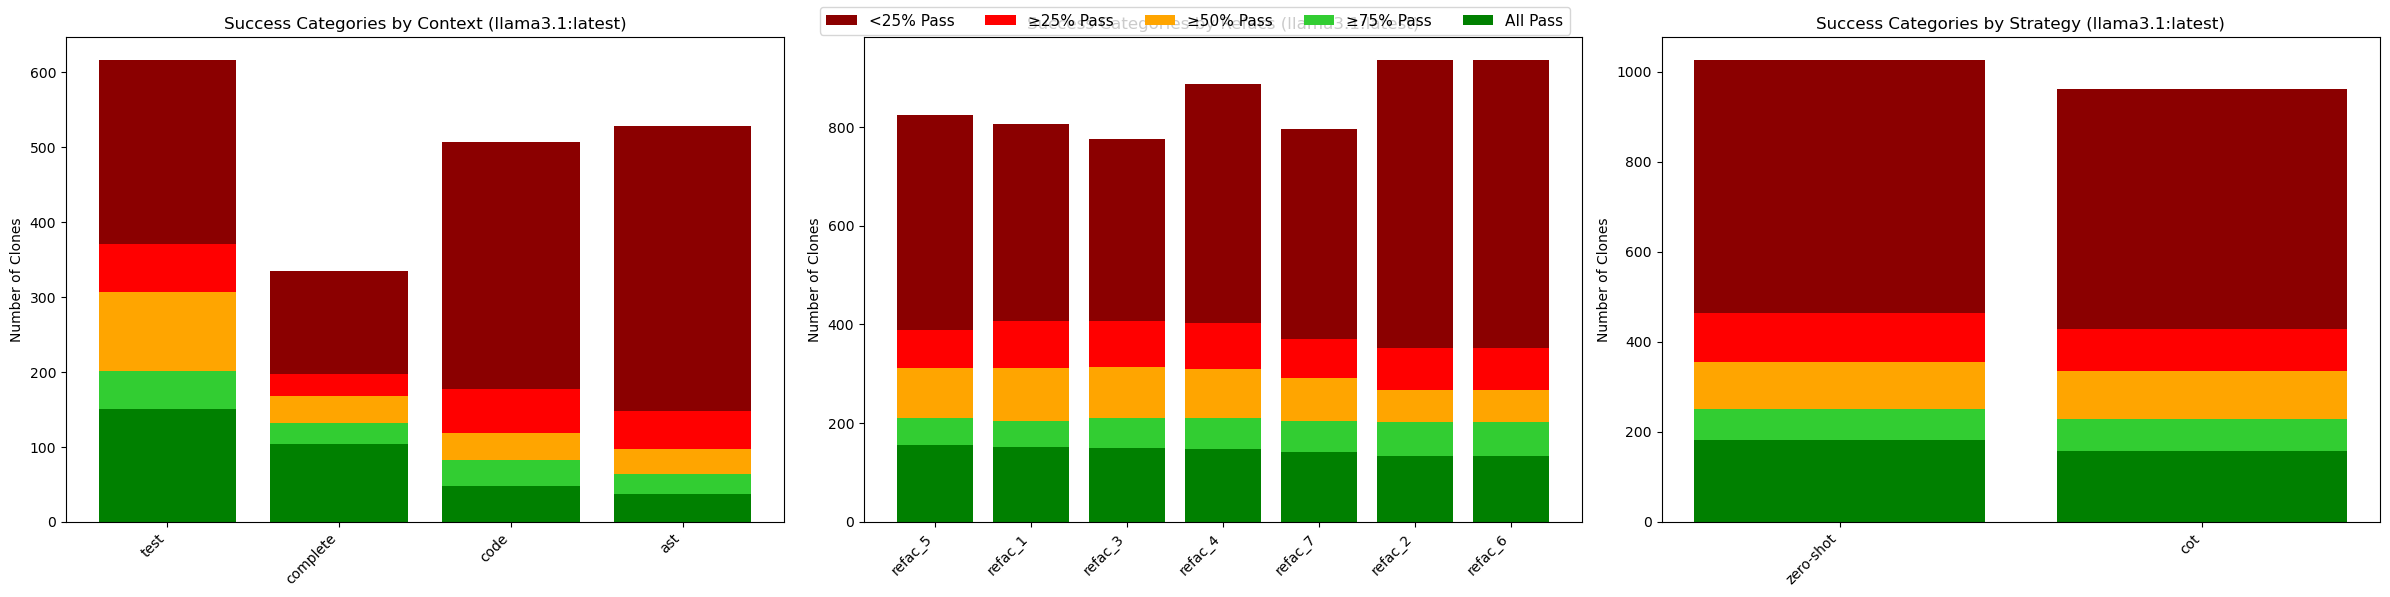

In [18]:
import json
import matplotlib.pyplot as plt

# Load dataset
with open(FILTERED_PATH_CODEBLEU, "r", encoding="utf-8") as f:
    dataset = json.load(f)

categories = ["All Pass", "≥75% Pass", "≥50% Pass", "≥25% Pass", "<25% Pass"]
colors = ["green", "limegreen", "orange", "red", "darkred"]

def classify_clone(results, num_tests):
    num_pass = sum(1 for v in results.values() if v.upper() == "PASS")
    ratio = num_pass / num_tests if num_tests > 0 else 0

    if ratio == 1.0:
        return "All Pass"
    elif ratio >= 0.75:
        return "≥75% Pass"
    elif ratio >= 0.50:
        return "≥50% Pass"
    elif ratio >= 0.25:
        return "≥25% Pass"
    else:
        return "<25% Pass"

def plot_grouped(ax, grouped_dict):
    # Sort descending by "All Pass"
    sorted_items = sorted(grouped_dict.items(), key=lambda kv: kv[1]["All Pass"], reverse=True)
    filters, grouped_sorted = zip(*sorted_items) if sorted_items else ([], [])

    x = range(len(filters))
    bottoms = [0] * len(filters)
    for cat, color in zip(categories, colors):
        values = [grouped_sorted[i][cat] for i in range(len(filters))]
        ax.bar(x, values, bottom=bottoms, label=cat, color=color)
        bottoms = [b + v for b, v in zip(bottoms, values)]

    ax.set_xticks(x)
    ax.set_xticklabels(filters, rotation=45, ha="right", fontsize=10)
    ax.set_ylabel("Number of Clones")
    return ax

# Detect all models present
models = sorted({clone.get("model", "unknown") for entry in dataset for clone in entry.get("clones", [])})

# One figure per model
for model in models:
    grouped_context = {}
    grouped_refacs = {}
    grouped_strategy = {}

    for entry in dataset:
        num_tests = max((len(clone.get("test_results", {})) for clone in entry.get("clones", [])), default=0)

        for clone in entry.get("clones", []):
            if clone.get("model") != model:
                continue

            context = clone.get("context", "unknown")
            refacs_list = clone.get("refacs", ["unknown"])
            strategy = clone.get("strategy", "unknown")
            results = clone.get("test_results", {})

            # Fill missing tests as ERROR
            for i in range(num_tests - len(results)):
                results[f"missing_test_{i+1}"] = "ERROR"

            category = classify_clone(results, num_tests)

            # Group by context
            grouped_context.setdefault(context, {c: 0 for c in categories})
            grouped_context[context][category] += 1

            # Group by refacs individually
            for refac in refacs_list:
                grouped_refacs.setdefault(refac, {c: 0 for c in categories})
                grouped_refacs[refac][category] += 1

            # Group by strategy
            grouped_strategy.setdefault(strategy, {c: 0 for c in categories})
            grouped_strategy[strategy][category] += 1

    # Plot for this model (3 panels)
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))
    plot_grouped(axes[0], grouped_context).set_title(f"Success Categories by Context ({model})")
    plot_grouped(axes[1], grouped_refacs).set_title(f"Success Categories by Refacs ({model})")
    plot_grouped(axes[2], grouped_strategy).set_title(f"Success Categories by Strategy ({model})")

    # Unified legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles[::-1], labels[::-1], fontsize=11, loc="upper center", ncol=len(categories))

    plt.tight_layout()  # leave space for legend
    plt.show()


## Summary

### Dataset filtered by original code 

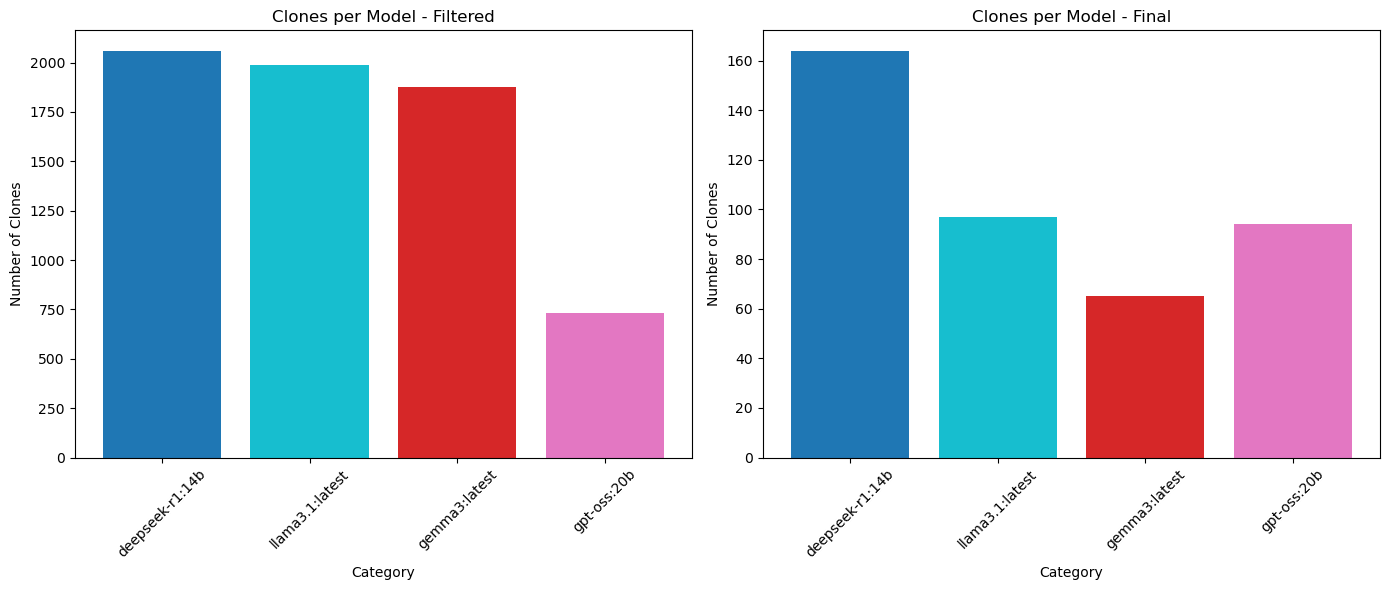

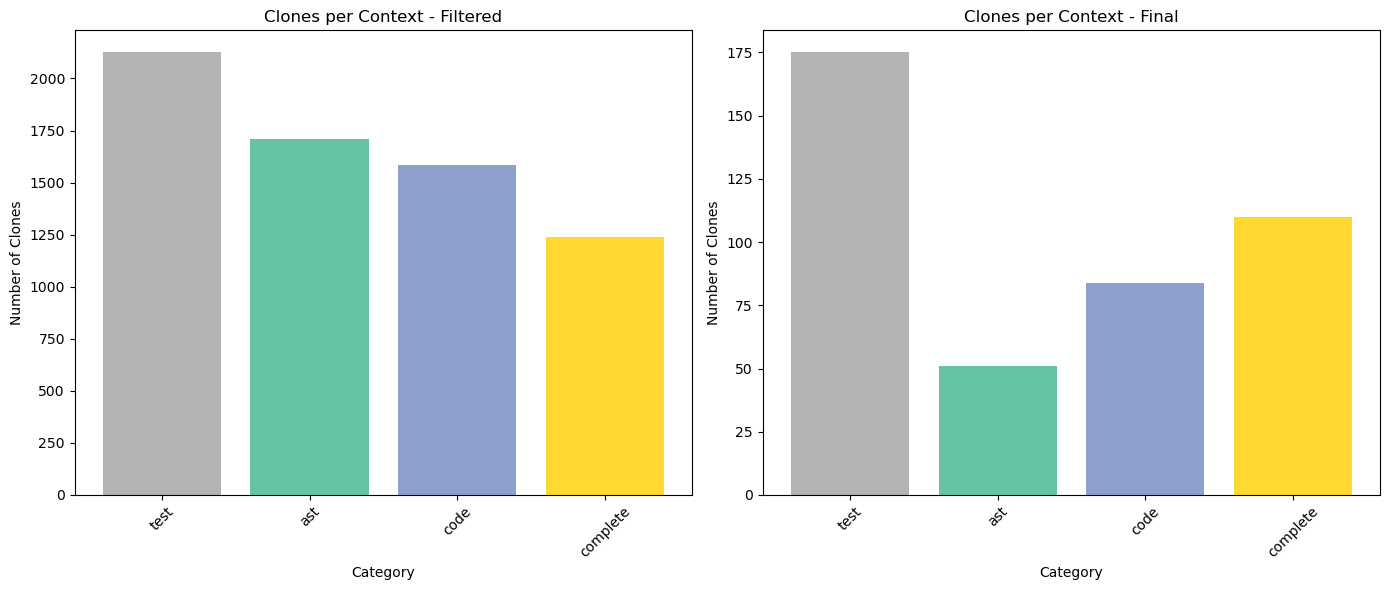

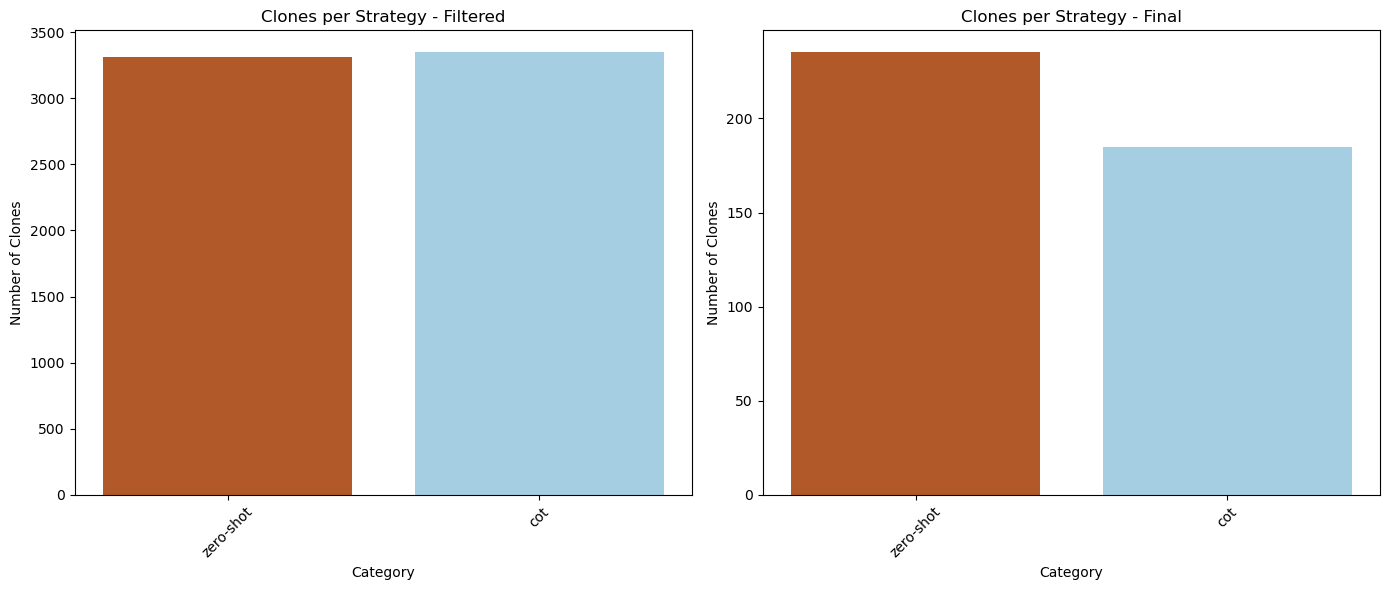

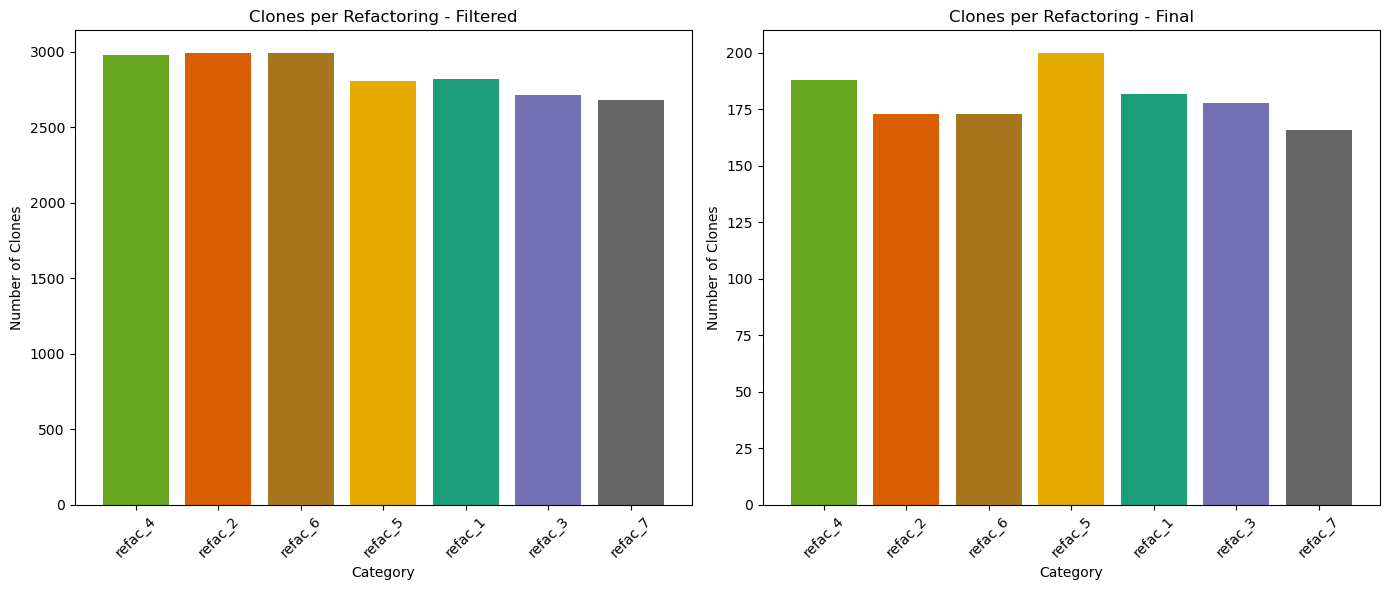

In [19]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import json
from collections import Counter

# --- Fixed global color palettes ---
FIXED_COLORS = {
    "models": plt.cm.tab10,
    "contexts": plt.cm.Set2,
    "strategies": plt.cm.Paired,
    "refacs": plt.cm.Dark2
}

def flatten_refacs(refacs):
    """Flatten nested lists and convert all items to strings."""
    flat = []
    if isinstance(refacs, str):
        flat.append(refacs)
    elif isinstance(refacs, list):
        for item in refacs:
            flat.extend(flatten_refacs(item))
    else:
        flat.append(str(refacs))
    return flat

def get_fixed_colors(labels, cmap):
    """Assign consistent colors to each label based on sorted order."""
    n = len(labels)
    return {label: cmap(i / max(1, n - 1)) for i, label in enumerate(sorted(labels))}

def summarize_clones(data):
    """Count occurrences of models, contexts, strategies, and refacs."""
    model_counts = Counter()
    context_counts = Counter()
    strategy_counts = Counter()
    refac_counts = Counter()

    for entry in data:
        for clone in entry.get("clones", []):
            model_counts[clone.get("model", "Unknown")] += 1
            context_counts[clone.get("context", "Unknown")] += 1
            strategy_counts[clone.get("strategy", "Unknown")] += 1

            # Flatten refacs
            refacs = clone.get("refacs", [])
            for ref in flatten_refacs(refacs):
                refac_counts[ref] += 1

    return {
        "models": model_counts,
        "contexts": context_counts,
        "strategies": strategy_counts,
        "refacs": refac_counts
    }

def plot_comparison(counter1, counter2, title, label1="Dataset 1", label2="Dataset 2", cmap=plt.cm.tab10):
    """Plot two bar charts side by side with fixed colors and sorted by descending count."""
    # Merge counters to get union of all labels
    all_labels = sorted(set(counter1.keys()) | set(counter2.keys()))
    color_map = get_fixed_colors(all_labels, cmap)

    # Sort labels by total counts descending (counter1 + counter2)
    total_counts = {label: counter1.get(label, 0) + counter2.get(label, 0) for label in all_labels}
    sorted_labels = sorted(total_counts, key=lambda k: total_counts[k], reverse=True)

    values1 = [counter1.get(label, 0) for label in sorted_labels]
    values2 = [counter2.get(label, 0) for label in sorted_labels]
    colors = [color_map[label] for label in sorted_labels]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

    # Left plot
    axes[0].bar(sorted_labels, values1, color=colors)
    axes[0].set_title(f"{title} - {label1}")
    axes[0].set_xlabel("Category")
    axes[0].set_ylabel("Number of Clones")
    axes[0].tick_params(axis="x", rotation=45)

    # Right plot
    axes[1].bar(sorted_labels, values2, color=colors)
    axes[1].set_title(f"{title} - {label2}")
    axes[1].set_xlabel("Category")
    axes[1].set_ylabel("Number of Clones")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


# --- Load datasets ---
with open(FILTERED_PATH_CODEBLEU, "r") as f:
    data1 = json.load(f)
with open(FINAL_DATASET, "r") as f:
    data2 = json.load(f)

# Ensure list format
if isinstance(data1, dict):
    data1 = [data1]
if isinstance(data2, dict):
    data2 = [data2]

# --- Summarize ---
summary1 = summarize_clones(data1)
summary2 = summarize_clones(data2)

# --- Plot comparisons ---
plot_comparison(summary1["models"], summary2["models"], "Clones per Model", "Filtered", "Final", cmap=FIXED_COLORS["models"])
plot_comparison(summary1["contexts"], summary2["contexts"], "Clones per Context", "Filtered", "Final", cmap=FIXED_COLORS["contexts"])
plot_comparison(summary1["strategies"], summary2["strategies"], "Clones per Strategy", "Filtered", "Final", cmap=FIXED_COLORS["strategies"])
plot_comparison(summary1["refacs"], summary2["refacs"], "Clones per Refactoring", "Filtered", "Final", cmap=FIXED_COLORS["refacs"])


## Driving factors

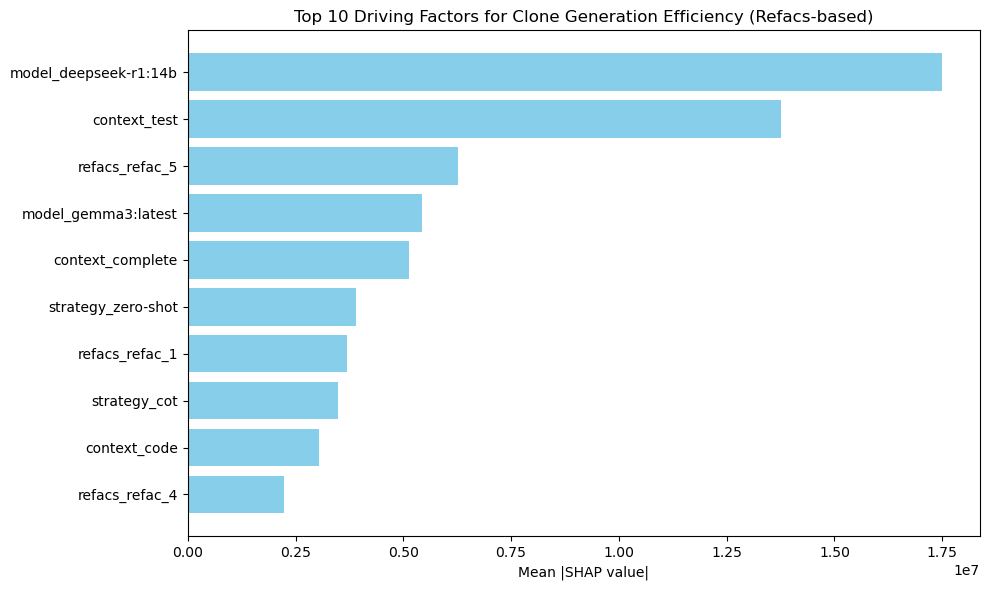

Top 10 driving factors:
                  feature    importance
0   model_deepseek-r1:14b  1.749967e+07
7            context_test  1.375816e+07
12         refacs_refac_5  6.266756e+06
1     model_gemma3:latest  5.425697e+06
6        context_complete  5.126009e+06
16     strategy_zero-shot  3.903762e+06
8          refacs_refac_1  3.687751e+06
15           strategy_cot  3.487976e+06
5            context_code  3.033245e+06
11         refacs_refac_4  2.233739e+06


In [22]:
import json
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt

# === Load dataset ===
with open(FINAL_DATASET, "r", encoding="utf-8") as f:
    dataset = json.load(f)

records = []
ORIGINAL_WEIGHT = 3.0  # weight for original code in avg_codebleu

for entry in dataset:
    entry_id = entry.get("id", "unknown")
    for clone in entry.get("clones", []):
        metrics = clone.get("metrics", {})
        if not isinstance(metrics, dict):
            metrics = {}

        codebleu_dict = metrics.get("codebleu", {})
        if not isinstance(codebleu_dict, dict) or not codebleu_dict:
            continue

        original_score = codebleu_dict.get("originalcode", 0.0)
        other_scores = [v for k, v in codebleu_dict.items() if k != "originalcode" and isinstance(v, (int, float))]

        weighted_sum = ORIGINAL_WEIGHT * original_score + sum(other_scores)
        total_weight = ORIGINAL_WEIGHT + len(other_scores)
        avg_codebleu = weighted_sum / total_weight if total_weight > 0 else 0.0

        # Efficiency proxy: more diverse clones = higher score
        efficiency_score = 1.0 / (avg_codebleu + 1e-9)

        # Handle refacs as a list (some may have multiple refactorings)
        refacs_list = clone.get("refacs", ["unknown"])
        if isinstance(refacs_list, str):
            refacs_list = [refacs_list]
        elif not isinstance(refacs_list, list):
            refacs_list = ["unknown"]

        for refac in refacs_list:
            records.append({
                "model": clone.get("model", "unknown"),
                "context": clone.get("context", "unknown"),
                "refacs": refac,
                "strategy": clone.get("strategy", "unknown"),
                "efficiency_score": efficiency_score
            })

df = pd.DataFrame(records)

# === One-hot encode categorical variables ===
X = df[["model", "context", "refacs", "strategy"]]
y = df["efficiency_score"]

encoder = OneHotEncoder(sparse_output=False)
X_encoded = encoder.fit_transform(X)

# === Train Random Forest ===
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_encoded, y)

# === SHAP analysis ===
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_encoded)

# Aggregate mean absolute SHAP values for feature importance
feature_names = encoder.get_feature_names_out(X.columns)
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": abs(shap_values).mean(axis=0)
}).sort_values(by="importance", ascending=False)

# === Plot top 10 driving factors ===
plt.figure(figsize=(10, 6))
plt.barh(
    y=importance_df["feature"].head(10),
    width=importance_df["importance"].head(10),
    color="skyblue"
)
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP value|")
plt.title("Top 10 Driving Factors for Clone Generation Efficiency (Refacs-based)")
plt.tight_layout()
plt.show()

# === Print top factors ===
print("Top 10 driving factors:")
print(importance_df.head(10))


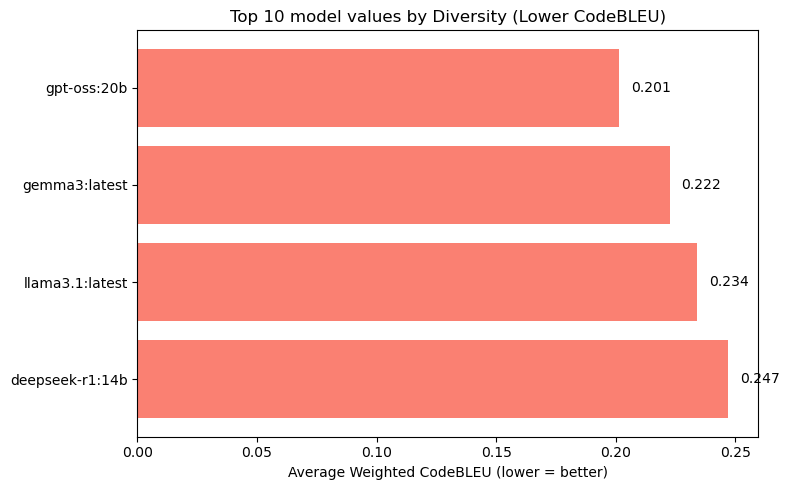

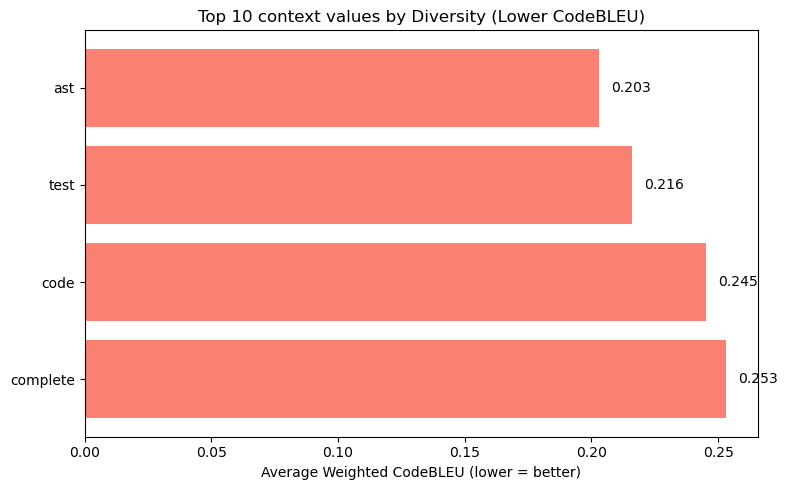

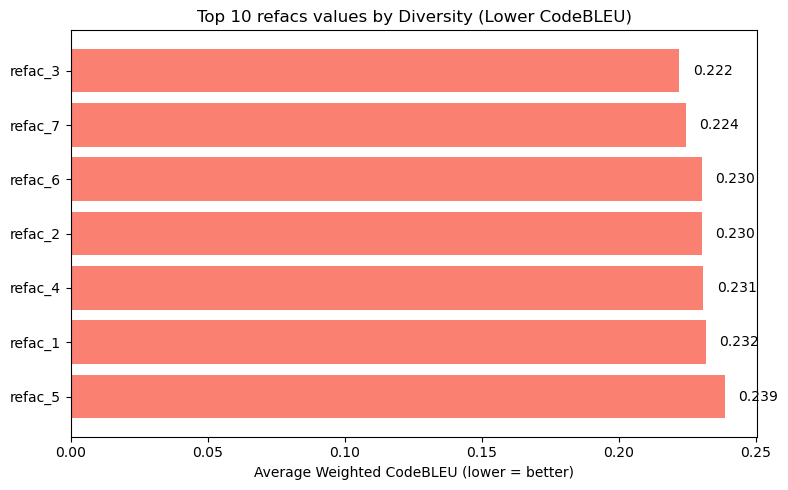

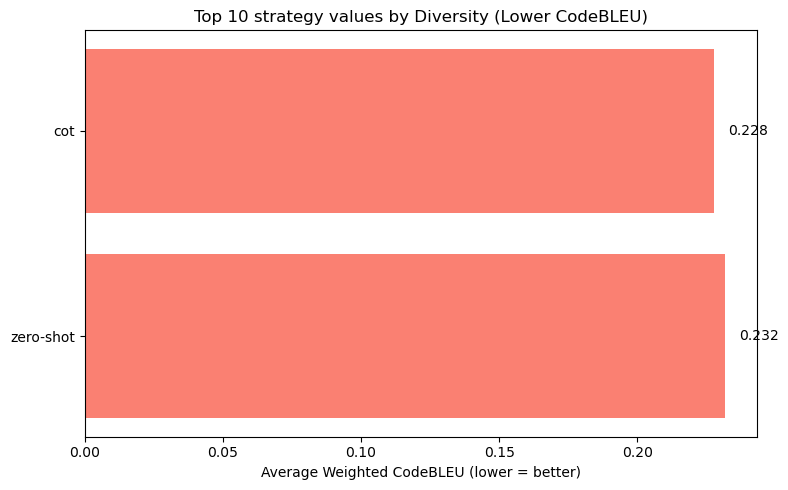

In [23]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# === Load dataset ===
with open(FINAL_DATASET, "r", encoding="utf-8") as f:
    dataset = json.load(f)

records = []
ORIGINAL_WEIGHT = 3.0  # weight for original code in avg_codebleu

for entry in dataset:
    for clone in entry.get("clones", []):
        codebleu_dict = clone.get("metrics", {}).get("codebleu", {})
        if not codebleu_dict or isinstance(codebleu_dict, float):
            continue

        original_score = codebleu_dict.get("originalcode", 0.0)
        other_scores = [v for k, v in codebleu_dict.items() if k != "originalcode"]

        weighted_sum = ORIGINAL_WEIGHT * original_score + sum(other_scores)
        total_weight = ORIGINAL_WEIGHT + len(other_scores)
        avg_codebleu = weighted_sum / total_weight if total_weight > 0 else 0.0

        # Handle refacs possibly being a list
        refacs_list = clone.get("refacs", ["unknown"])
        if not isinstance(refacs_list, list):
            refacs_list = [refacs_list]

        for refac in refacs_list:
            records.append({
                "model": clone.get("model", "unknown"),
                "context": clone.get("context", "unknown"),
                "refacs": refac,
                "strategy": clone.get("strategy", "unknown"),
                "avg_codebleu": avg_codebleu
            })

df = pd.DataFrame(records)

def plot_factor(df, factor, top_n=10):
    # Sort by ascending avg_codebleu (lower is better)
    summary = df.groupby(factor)["avg_codebleu"].mean().sort_values(ascending=True)
    summary = summary.head(top_n)
    
    plt.figure(figsize=(8, 5))
    plt.barh(summary.index.astype(str), summary.values, color="salmon")
    plt.gca().invert_yaxis()  # lowest CodeBLEU at the top
    plt.xlabel("Average Weighted CodeBLEU (lower = better)")
    plt.title(f"Top {top_n} {factor} values by Diversity (Lower CodeBLEU)")
    
    # Annotate bars
    for i, val in enumerate(summary.values):
        plt.text(val + 0.005, i, f"{val:.3f}", va='center')
    
    plt.tight_layout()
    plt.show()

# === Plot each factor ===
for factor in ["model", "context", "refacs", "strategy"]:
    plot_factor(df, factor, top_n=10)
